# Plantilla: espectros de frecuencia de un sismo con el Acelerógrafo UdeA y las estaciones del SGC

Este notebook complementa `plantilla_analisis_sismo.ipynb`: aquella compara los registros **en el tiempo** y
esta los compara **en frecuencia**. Usa los mismos datos, carpetas y configuración, y las mismas funciones de
lectura (las dos las importan de `sismo_utils.py`), así que las señales y las horas son idénticas en los dos notebooks. Solo hay que editar **la celda de
configuración (§3)** y hacer **Run All**.

Qué hace:

1. **Espectro de amplitud de Fourier** de cada componente (Z, N, E) en cada ventana de tiempo: el Acelerógrafo
   UdeA y cada estación del SGC superpuestos en escala log-log, cada uno con el espectro de su **ruido antes del
   sismo**. De ahí salen la **frecuencia dominante** y la **banda útil** del Acelerógrafo UdeA (donde la señal
   supera al ruido).
2. **Espectrograma comparativo**: tiempo × frecuencia del Acelerógrafo UdeA al lado de cada estación (y de cada
   grupo de estaciones), con la **misma escala de color**, las franjas de alerta y los tramos interpolados.
3. **Vista CNN**: los espectrogramas de **65×11×3** que calculó el nodo para cada alerta. Es exactamente la
   entrada con la que la red neuronal del firmware decidió disparar.

Todo se guarda en `output/<SISMO>/espectros/`. La configuración por defecto es la del Chocó (2026-08-10, M7.4),
así que el notebook funciona tal cual como ejemplo.

| Sección | Contenido |
|---|---|
| §1 | Guía: datos, cómo leer cada análisis, banda útil del Acelerógrafo UdeA, ruido, tramos interpolados, salidas |
| §2 | Librerías y constantes (sensor, firmware y CNN) |
| §3 | **Configuración (la única celda que se edita)** |
| §4 | Verificación de la configuración |
| §5–§7 | Funciones de lectura (Acelerógrafo UdeA, SGC, ventanas): las de la plantilla, en `sismo_utils.py` |
| §8–§9 | Funciones de espectros y de gráficas |
| §10–§11 | Ejecución: reconstrucción del Acelerógrafo UdeA y estaciones del SGC |
| §12 | Espectros de Fourier |
| §13 | Espectrogramas comparativos |
| §14 | Espectrogramas de las alertas (vista CNN) |
| §15 | Resumen: frecuencias dominantes, banda útil, alertas, avisos y archivos generados |

## §1 — Guía

### 1.1 Datos y configuración

Se usan **los mismos datos y las mismas claves de configuración** que en `plantilla_analisis_sismo.ipynb` (ver
su §1): los `.bin` del Acelerógrafo UdeA en `aceleraciones/` y `eventos/`, los `.anc`/`.mseed` del SGC en `sgc/`
y la misma forma de nombrar estaciones, ventanas y grupos. Si la plantilla ya corre para un sismo, basta copiar
su configuración en §3 (más las claves espectrales) y hacer Run All.

Las funciones de lectura (§5–§7) son las de la plantilla, en `sismo_utils.py`: la señal del Acelerógrafo UdeA se reconstruye igual
y la hora de cada archivo es la de su nombre. Las estaciones del SGC se cargan con la misma regla de fuentes
(`.mseed` calibrado con el `.anc`, solo `.anc` o solo `.mseed`).

### 1.2 Cómo leer cada análisis

| Análisis | Qué muestra | Para qué sirve |
|---|---|---|
| **Espectro de Fourier** | amplitud de Fourier \|X(f)\|·Δt de cada componente en la ventana, suavizada (Konno-Ohmachi) y en log-log; en línea discontinua, el ruido antes del sismo | ver qué frecuencias dominan el movimiento, comparar la amplitud del UdeA y del SGC frecuencia por frecuencia y hallar la banda útil del UdeA |
| **Espectrograma** | la densidad espectral de potencia (PSD) en ventanas cortas que se deslizan en el tiempo, en dB | ver cómo cambia el contenido de frecuencia con la llegada de las ondas P, S y superficiales, y qué registra cada instrumento en el mismo instante |
| **Vista CNN** | los espectrogramas 65×11×3 de cada alerta (FFT de 128 puntos, Hann, salto de 64, `log10(PSD)` en g²/Hz) | ver el patrón que llevó a la red neuronal del nodo a disparar cada alerta |

- **Unidades del espectro de Fourier**: aceleración × tiempo, es decir **g·s** o **cm/s**. Se genera una
  gráfica por unidad de `UNIDADES`.
- **Frecuencia pico**: el máximo del espectro suavizado entre 0.2 y 20 Hz, que es la banda donde el filtro del
  Acelerógrafo UdeA es plano (1.3): por debajo de ~0.2 Hz el pasa-altos de 0.1 Hz ya atenúa. Se usa la misma banda
  en todos los instrumentos para que los picos se puedan comparar.
- **Banda útil**: el tramo continuo de frecuencias alrededor del pico donde el espectro de la señal es al menos
  `FOURIER["snr_min"]` veces el del ruido (SNR ≥ 3 por defecto). Fuera de esa banda el espectro es ruido.
- **Espectrograma**: la ventana deslizante define la resolución. Con `ventana_s = 5.12` la resolución es de
  1/5.12 ≈ 0.2 Hz y cada columna promedia 5 s. Una ventana más corta da más detalle en el tiempo y menos en
  frecuencia. Con `ventana_s = 0.64`, `solape = 0.5`, `escala = "lineal"` y `fmax = 100` se obtiene el mismo
  espectrograma que usa la CNN y que dibuja `post_analysis.ipynb`.

### 1.3 Banda útil del Acelerógrafo UdeA

- El firmware del nodo (`platform_acel/acel_ubuntu/src/config.h` del repositorio `pandemaiz`) filtra la señal
  antes de guardarla: pasa-altos de 0.1 Hz y pasa-bajos de 20 Hz (Butterworth de 2.º orden). Por encima de
  20 Hz el espectro de los `.bin` continuos cae, y lo que queda es sobre todo el **ruido de cuantización** del
  ADXL345 (3.9 mg por cuenta, del orden de 10⁻⁸ g²/Hz). En las gráficas de Fourier esa zona va sombreada.
- Los `.bin` de **eventos** guardan la ventana de 4 s que analizó la CNN. La CNN usa la señal **solo con el
  pasa-altos**, porque el modelo se entrenó así, y por eso esos archivos tienen energía hasta 100 Hz. En los datos
  del Chocó tienen unas 10 veces más PSD por encima de 30 Hz que los continuos. La vista CNN (§14) va de 0 a
  100 Hz y marca 20 Hz con una línea discontinua.
- El ADXL345 tiene un piso de ruido mucho más alto que los acelerógrafos del SGC. Las líneas discontinuas del
  espectro de Fourier lo muestran para cada instrumento.

### 1.4 Ruido y relación señal/ruido

- El ruido de cada instrumento se toma de **su propio registro**: `RUIDO["duracion_s"]` segundos que terminan
  `RUIDO["fin_antes_origen_s"]` segundos antes de la hora de origen del sismo. Si no se conoce la hora de origen,
  se usa el tramo anterior a la primera alerta del Acelerógrafo UdeA.
- La amplitud de Fourier de un ruido estacionario crece como √T. Por eso el espectro del ruido se multiplica por
  √(T_señal / T_ruido) antes de compararlo con la señal de la ventana.
- Si un registro no alcanza a cubrir toda la ventana de ruido (un `.anc` sin `.mseed` empieza solo 30 s antes del
  origen), se usa lo que haya. Con menos de 2 s de ruido no se dibuja.

### 1.5 Tramos interpolados

La reconstrucción, igual a la de la plantilla, rellena por interpolación lineal los huecos que los eventos no
cubren. En el Chocó son 106 s de 3590 s: casi todos de ~1 s entre archivos y uno largo durante el sismo. Una
recta no tiene energía en alta frecuencia, así que en el espectrograma esos tramos se ven como franjas verticales
oscuras. Por eso se marcan con una **barra gris** en la parte baja de cada panel del Acelerógrafo UdeA, y el
resumen (§15) da el porcentaje interpolado de cada ventana.

### 1.6 Archivos de salida

```
output/<sismo>/espectros/
├── acelerografo/        espectrograma_hora_completa_{UTC,LOCAL}.png
├── alertas_cnn/         alertas_cnn_{1,2,...}.png
└── <ventana>/
    ├── acelerografo/    fourier_acelerografo_<ventana>_{g,cms2}.png
    │                    espectrograma_acelerografo_<ventana>_{UTC,LOCAL}.png
    ├── <Estacion>/      <municipio>_<CODIGO>_<LOC>_fourier_junta_{g,cms2}.png
    │                    <municipio>_<CODIGO>_<LOC>_espectrograma_junta_{UTC,LOCAL}.png
    └── juntas_<grupo>/  juntas_<grupo>_fourier_{g,cms2}.png
                         juntas_<grupo>_espectrograma_{UTC,LOCAL}.png
```

- `junta` = el Acelerógrafo UdeA (negro) y la estación (rojo) en la misma gráfica de Fourier, o en columnas
  vecinas en el espectrograma. No hay versiones `propia` ni `sgc` porque la `junta` ya las muestra por separado.
- Si una estación no está calibrada (solo `.mseed`), su espectro de Fourier sale como `_fourier_junta_norm`, con
  cada curva dividida por su máximo, y en el espectrograma tiene su propia barra de color en cuentas.
- Las gráficas de Fourier no tienen eje de tiempo, así que no se guardan por zona horaria: el encabezado da la
  ventana en UTC y en hora local. Los espectrogramas se guardan `_UTC` y `_LOCAL`, y en pantalla se muestra solo
  la primera zona horaria.

### 1.7 Checklist y problemas conocidos

1. Tener el sismo organizado como pide la plantilla (§1 de `plantilla_analisis_sismo.ipynb`).
2. En §3: copiar `SISMO`, las carpetas, `ESTACIONES_SGC`, `TITULO_UBICACION`, `VENTANAS` y `GRUPOS_ESTACIONES`
   de la plantilla. Revisar `RUIDO` (necesita la hora de origen, que se lee del `.anc` o de `ORIGEN_UTC`).
3. Ejecutar hasta §4: debe mostrar cuántos archivos encontró, sin errores.
4. Run All. La configuración del Chocó tarda unos 2 minutos. Revisar en §15 las frecuencias pico, la banda útil
   y los avisos.

- Si la ventana de ruido cae antes del inicio de un registro, ese instrumento sale sin ruido (hay un aviso en §15).
- La ventana del espectrograma (`ESPECTROGRAMA["ventana_s"]`) tiene que ser más corta que la ventana de tiempo.
  Si no lo es, esa gráfica se omite con un aviso.
- La hora de las alertas en la vista CNN es la del nombre del archivo del evento, igual que en la plantilla.

## §2 — Librerías y constantes

Constantes del sensor, del firmware y de la CNN del nodo: no dependen del sismo, no hace falta cambiarlas. Las
de la CNN vienen de `config.h`, `norm_constants.h` y `seismic_dataset_builder_v3.ipynb` del repositorio
`pandemaiz`.

Las funciones de lectura, las ventanas de tiempo, las piezas comunes de las gráficas y las constantes del sensor
vienen de **`sismo_utils.py`**, el mismo módulo que usa la plantilla. Si se edita ese archivo, hay que reiniciar
el kernel para que se vuelva a importar.

In [1]:
import pathlib
from datetime import timedelta

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.signal import detrend, spectrogram as scipy_spectrogram
from scipy.signal.windows import tukey

# Funciones y constantes comunes a los notebooks del sismo (sensor, componentes, estilo SGC): ver sismo_utils.py
from sismo_utils import (
    FS, LABELS, CANAL_POR_COMP, ORDEN_FILAS, BANDA_SGC,
    COLOR_ACEL, COLOR_SGC, COLOR_ALERTA, FIGSIZE, DPI,
    slug, nombre_ventana, unir_nombres, zonas_horarias, verificar_configuracion,
    get_starttime_local, local_to_utc, a_datetime64, parse_bin, discover_bins, extraer_score,
    reconstruct_full_hour, imprimir_reconstruccion,
    leer_mseed_carpeta, cargar_estaciones, datos_evento, buscar_estacion,
    resolver_ventana, convertir,
    alertas_en_rango, encabezado, casilla_ids, mostrar_o_cerrar,
)

# -- Firmware del Acelerógrafo UdeA (config.h) -----------------------------------
BANDA_FILTRO_UDEA = (0.1, 20.0)   # Hz: pasa-altos y pasa-bajos de los .bin continuos (los eventos solo el pasa-altos)

# -- CNN del detector (config.h, norm_constants.h, seismic_dataset_builder_v3) -----
CNN_VENTANA       = 800                       # muestras = 4 s a 200 Hz
CNN_NPERSEG       = 128                       # FFT de 128 puntos con ventana Hann
CNN_NOVERLAP      = 64                        # salto de 64 muestras -> 11 ventanas en 4 s
CNN_ORDEN_CANALES = ["EW", "VER", "NS"]       # orden de los canales en la entrada de la CNN
CNN_NORM_MEAN     = -7.98922157               # z-score del log10(PSD) (training set)
CNN_NORM_STD      = 1.37405312
CNN_UMBRAL        = 0.05                      # puntaje > umbral -> sismo
CNN_MIN_LOG_PSD   = -11.0                     # media del log10(PSD) mínima para que el nodo evalúe la CNN

# -- Estilo propio de los espectros (el resto del formato SGC viene de sismo_utils.py) ------
COLOR_INTERP = "#9E9E9E"
COLOR_FUERA_BANDA = "0.88"

_ETIQUETA_FAS   = {"g": "g·s", "cm/s²": "cm/s", "norm": "normalizado"}
_ETIQUETA_PSD   = {"g": "dB re 1 g²/Hz", "cm/s²": "dB re 1 (cm/s²)²/Hz", "cuentas": "dB re 1 cuenta²/Hz"}
_SUFIJO_UNIDAD  = {"g": "g", "cm/s²": "cms2", "cuentas": "cuentas", "norm": "norm"}

print("Librerías y constantes cargadas.")

Librerías y constantes cargadas.


## §3 — Configuración

> **La única celda que hay que editar para analizar otro sismo.** Las claves 1–10 son las mismas de
> `plantilla_analisis_sismo.ipynb` (§4 de la plantilla). Las claves 11–15 son las de los espectros (§1.2–§1.4).

In [2]:
# -- 1) Sismo -------------------------------------------------------------------------
SISMO = "terremoto_choco"          # nombre de la carpeta de datos y de la carpeta de salida

# -- 2) Carpetas de entrada (las mismas de plantilla_analisis_sismo.ipynb) ----------------
DIR_SISMO   = pathlib.Path("data/sismos") / SISMO
DIR_ACEL    = DIR_SISMO / "aceleraciones"
DIR_EVENTOS = DIR_SISMO / "eventos"
DIR_SGC     = DIR_SISMO / "sgc"
# El Chocó está en la estructura antigua. PARA UN SISMO NUEVO, BORRAR ESTAS 3 LÍNEAS:
DIR_ACEL    = pathlib.Path("data/aceleraciones/terremoto_choco")
DIR_EVENTOS = pathlib.Path("data/eventos/terremoto_choco")
DIR_SGC     = pathlib.Path("data/Datos_SGC_Terremoto_Choco")

# -- 3) Carpeta de salida --------------------------------------------------------------------
DIR_SALIDA = pathlib.Path("output") / SISMO / "espectros"

# -- 4) Acelerógrafo UdeA ----------------------------------------------------------------------
ACELEROGRAFO = {
    "nombre":  "Acelerógrafo UdeA (Medellín)",   # en los títulos
    "leyenda": "Acelerógrafo UdeA",              # en las leyendas
    "red": "PAN", "codigo": "PANUDEA01", "loc": "",
}

# -- 5) Estaciones del SGC (§1.4 de la plantilla). Orden = orden de dibujo en los grupos -------
ESTACIONES_SGC = [
    {"nombre": "Riosucio", "codigo": "RIO2C", "red": "CM", "loc": "10", "color": "#A5D6A7"},
    {"nombre": "Pereira",  "codigo": "CBOCA", "red": "CM", "loc": "10", "color": "#90CAF9"},
    {"nombre": "Dabeiba",  "codigo": "DBB",   "red": "CM", "loc": "10", "color": "#EF9A9A"},
]
# Claves opcionales por estación: "fuente": "auto" | "mseed" | "anc",
#                                 "inicio_anc_utc": "YYYY-MM-DD HH:MM:SS",
#                                 "escala_cms2_por_cuenta": 2.36e-4

# -- 6) Datos del evento (None = tomarlos de la cabecera del .anc) ----------------------------
TITULO_UBICACION = "San José del Palmar - Chocó"   # el .anc trae las tildes como "?"
MAGNITUD   = None
ORIGEN_UTC = None                                  # p. ej. "2026-08-10 12:34:27" (obligatorio si no hay .anc)

# -- 7) Zonas horarias y unidades ---------------------------------------------------------
TZ_OFFSET_HORAS     = -5          # hora local de Colombia = UTC-5
ETIQUETA_ZONA_LOCAL = "COT"
ZONAS    = ["UTC", "LOCAL"]       # zonas de los espectrogramas
UNIDADES = ["g", "cm/s²"]         # unidades de los espectros de Fourier

# -- 8) Parámetros de procesamiento ----------------------------------------------------------
ANC_INICIO_OFFSET_S = -30   # inicio estimado del .anc respecto al origen, si no hay .mseed
BASELINE_S          = 20    # segundos iniciales (tranquilos) para quitar la línea base del Acelerógrafo UdeA

# -- 9) Ventanas de tiempo (§1.6 de la plantilla): cada una genera su propio juego de gráficas --
VENTANAS = [
    {"nombre": "registro_sgc",         "modo": "estacion"},
    {"nombre": "desde_primera_alerta", "modo": "primera_alerta"},
    {"nombre": "sismo",                "modo": "relativa_origen", "antes_s": 0, "despues_s": 300},
    # {"nombre": "manual", "modo": "manual", "inicio": "2026-08-10 07:34:00", "fin": "2026-08-10 07:40:00", "zona": "LOCAL"},
    # {"nombre": "hora",   "modo": "hora_completa"},
]

# -- 10) Grupos de estaciones juntas (UdeA primero + las estaciones del grupo, en ese orden) ----
GRUPOS_ESTACIONES = {
    "todas": ["Riosucio", "Pereira", "Dabeiba"],
    # "cercanas": ["Riosucio", "Pereira"],
}

# -- 11) Ruido antes del sismo (§1.4) ----------------------------------------------------------
RUIDO = {"duracion_s": 60, "fin_antes_origen_s": 10}   # ruido = [origen - 70 s, origen - 10 s]

# -- 12) Espectro de Fourier (§1.2) ------------------------------------------------------------
FOURIER = {
    "fmin": 0.1, "fmax": 100,      # Hz, eje de frecuencias (fmax <= 100 Hz, la mitad de 200 Hz)
    "konno_ohmachi_b": 40,         # ancho del suavizado (40 = el usual; menor = más suave)
    "n_frecuencias": 400,          # frecuencias del espectro suavizado (espaciadas en escala log)
    "taper": 0.05,                 # fracción de la ventana ahusada (Tukey)
    "snr_min": 3,                  # relación señal/ruido mínima para la banda útil
}

# -- 13) Espectrograma (§1.2) ------------------------------------------------------------------
ESPECTROGRAMA = {
    "ventana_s": 5.12,             # duración de cada ventana deslizante (resolución = 1/ventana_s Hz)
    "solape": 0.9,                 # fracción de solape entre ventanas
    "fmin": 0.2, "fmax": 25,       # Hz, eje de frecuencias
    "escala": "log",               # "log" o "lineal"
    "rango_db": 60,                # dB entre el color más claro y el más oscuro
    "cmap": "magma",
    "unidad": "g",                 # "g" = dB re g²/Hz (como el firmware) o "cm/s²"
}

# -- 14) Vista CNN (§14) ---------------------------------------------------------------------
CNN = {"alertas_por_figura": 6, "vmin": -9.5, "vmax": -4.5}   # escala de color en log10(PSD) g²/Hz

# -- 15) Qué generar -----------------------------------------------------------------------------
GENERAR_FOURIER        = True
GENERAR_ESPECTROGRAMAS = True
GENERAR_CNN            = True

## §4 — Verificación de la configuración

Revisa que existan las carpetas, cuenta los archivos y valida ventanas, grupos, zonas, unidades y parámetros de
los espectros antes de procesar nada.

In [3]:
ID_ACEL = f"{ACELEROGRAFO['red']}.{ACELEROGRAFO['codigo']}.{ACELEROGRAFO['loc']}"
PROBLEMAS = []      # avisos que se acumulan durante la ejecución y se listan en §15

print(f"Sismo: {SISMO}")
_errores = verificar_configuracion(DIR_ACEL, DIR_EVENTOS, DIR_SGC, ESTACIONES_SGC, GRUPOS_ESTACIONES, VENTANAS,
                                   ZONAS, UNIDADES, avisos=PROBLEMAS)

# -- parámetros de los espectros --
if not 0 < FOURIER["fmin"] < FOURIER["fmax"] <= FS / 2:
    _errores.append(f"FOURIER: debe cumplirse 0 < fmin < fmax <= {FS / 2:g} Hz")
if not 0 < ESPECTROGRAMA["fmin"] < ESPECTROGRAMA["fmax"] <= FS / 2:
    _errores.append(f"ESPECTROGRAMA: debe cumplirse 0 < fmin < fmax <= {FS / 2:g} Hz")
if not 0 <= ESPECTROGRAMA["solape"] < 1:
    _errores.append("ESPECTROGRAMA['solape'] debe estar entre 0 y 1 (sin incluir 1)")
if ESPECTROGRAMA["ventana_s"] * FS < 16:
    _errores.append("ESPECTROGRAMA['ventana_s'] es demasiado corta (mínimo 16 muestras)")
if ESPECTROGRAMA["unidad"] not in ("g", "cm/s²"):
    _errores.append("ESPECTROGRAMA['unidad'] debe ser 'g' o 'cm/s²'")
if ESPECTROGRAMA["escala"] not in ("log", "lineal"):
    _errores.append("ESPECTROGRAMA['escala'] debe ser 'log' o 'lineal'")
if RUIDO["duracion_s"] <= 0:
    _errores.append("RUIDO['duracion_s'] debe ser positiva")
if _errores:
    raise ValueError("Revisar la configuración (§3):\n  - " + "\n  - ".join(_errores))

_ZONAS_HORARIAS = zonas_horarias(ZONAS, TZ_OFFSET_HORAS, ETIQUETA_ZONA_LOCAL)
DIR_SALIDA.mkdir(parents=True, exist_ok=True)
print(f"Salidas en      : {DIR_SALIDA}")
print(f"Estaciones      : {[e['nombre'] for e in ESTACIONES_SGC]}")
print(f"Zonas / unidades: {[z[0] for z in _ZONAS_HORARIAS]}  /  {UNIDADES}")
print(f"Ventanas        : {[nombre_ventana(v) for v in VENTANAS]}")
print(f"Grupos juntos   : {list(GRUPOS_ESTACIONES)}")
print(f"Fourier         : {'sí' if GENERAR_FOURIER else 'no'} -- {FOURIER['fmin']:g}-{FOURIER['fmax']:g} Hz, "
      f"Konno-Ohmachi b={FOURIER['konno_ohmachi_b']}, ruido de {RUIDO['duracion_s']:g} s hasta "
      f"{RUIDO['fin_antes_origen_s']:g} s antes del origen")
print(f"Espectrogramas  : {'sí' if GENERAR_ESPECTROGRAMAS else 'no'} -- Hann de {ESPECTROGRAMA['ventana_s']:g} s "
      f"(resolución {1 / ESPECTROGRAMA['ventana_s']:.2f} Hz), solape {ESPECTROGRAMA['solape']:.0%}, "
      f"{ESPECTROGRAMA['fmin']:g}-{ESPECTROGRAMA['fmax']:g} Hz ({ESPECTROGRAMA['escala']}), "
      f"{_ETIQUETA_PSD[ESPECTROGRAMA['unidad']]}")
print(f"Vista CNN       : {'sí' if GENERAR_CNN else 'no'}")

Sismo: terremoto_choco
  aceleraciones:  58 archivo(s) *.bin    en data\aceleraciones\terremoto_choco
  eventos      :   6 archivo(s) *.bin    en data\eventos\terremoto_choco
  SGC .anc     :   3 archivo(s) *.anc    en data\Datos_SGC_Terremoto_Choco
  SGC .mseed   :   6 archivo(s) *.mseed  en data\Datos_SGC_Terremoto_Choco
Salidas en      : output\terremoto_choco\espectros
Estaciones      : ['Riosucio', 'Pereira', 'Dabeiba']
Zonas / unidades: ['UTC', 'Local (COT, UTC-5)']  /  ['g', 'cm/s²']
Ventanas        : ['registro_sgc', 'desde_primera_alerta', 'sismo']
Grupos juntos   : ['todas']
Fourier         : sí -- 0.1-100 Hz, Konno-Ohmachi b=40, ruido de 60 s hasta 10 s antes del origen
Espectrogramas  : sí -- Hann de 5.12 s (resolución 0.20 Hz), solape 90%, 0.2-25 Hz (log), dB re 1 g²/Hz
Vista CNN       : sí


## §5 — Funciones: Acelerógrafo UdeA

Están en `sismo_utils.py` (se importan en §2), el mismo módulo que usan `plantilla_analisis_sismo.ipynb` y `plantilla_espectros_sismo.ipynb`:

- `parse_bin()`: lee un `.bin` del ESP32 (cabecera `MAGIC/VERSION/SAMPLE_RATE(+lat/lon)` + muestras de 10
  bytes `timestamp_ms, ax, ay, az`; `ax`→EW, `ay`→NS, `az`→VER, 1 LSB = 3.9 mg).
- `reconstruct_full_hour()`: une la grabación continua en una grilla UTC a 200 Hz, rellena huecos con los
  eventos y el resto por interpolación lineal, quita la línea base (`BASELINE_S`) y devuelve las ventanas
  de alerta ordenadas por hora.

## §6 — Funciones: estaciones del SGC

Están en `sismo_utils.py` (se importan en §2), el mismo módulo que usan `plantilla_analisis_sismo.ipynb` y `plantilla_espectros_sismo.ipynb`:

- `parse_anc()`: lee un `.anc` (19 líneas de cabecera + encabezado de columnas + datos en cm/s²).
- `leer_mseed_carpeta()`: lee todos los `.mseed` de la carpeta en un solo `Stream`.
- `calibrar_canal_mseed()`: factor cuentas → cm/s² por correlación cruzada contra el `.anc`.
- `cargar_estacion()`: carga la estación con la mejor fuente disponible y la devuelve en un formato uniforme.
- `cargar_estaciones()` / `datos_evento()`: cargan todas las estaciones y toman del `.anc` los datos del evento (§11).

## §7 — Funciones: ventanas de tiempo y registros

- `resolver_ventana()` y `convertir()` vienen de `sismo_utils.py`, igual que en la plantilla.
- `registro_acelerografo()` / `registro_estacion()` recortan un instrumento a la ventana y lo pasan a la unidad
  pedida. Devuelven un diccionario con `t` (UTC), `datos` (N, 3) `[EW, NS, VER]`, `dt`, `unidad`, `id`, `nombre`,
  `color` y, en el Acelerógrafo UdeA, la máscara de las muestras `interpolado`. Una estación sin calibrar queda en
  cuentas.

In [6]:
def _registro(t, datos, dt, unidad, id_nslc, nombre, color, t0=None, t1=None, interpolado=None):
    """Registro recortado a [t0, t1] (ver §7); None si queda con menos de 2 muestras."""
    m = np.ones(len(t), dtype=bool)
    if t0 is not None:
        m &= t >= t0
    if t1 is not None:
        m &= t <= t1
    if m.sum() < 2:
        return None
    return {"t": t[m], "datos": datos[m], "dt": dt, "unidad": unidad, "id": id_nslc, "nombre": nombre,
            "color": color, "interpolado": None if interpolado is None else interpolado[m]}


def registro_acelerografo(unidad, t0=None, t1=None):
    return _registro(RECON["t_utc"], convertir(RECON["data_g"], "g", unidad), 1.0 / FS, unidad, ID_ACEL,
                     ACELEROGRAFO["leyenda"], COLOR_ACEL, t0, t1, interpolado=RECON["status"] == 3)


def registro_estacion(est, unidad, color=None, t0=None, t1=None):
    if est["calibrada"]:
        datos, unidad_reg = convertir(est["datos"], est["unidad"], unidad), unidad
    else:
        datos, unidad_reg = est["datos"], "cuentas"
    return _registro(est["t_utc"], datos, est["dt"], unidad_reg, est["id"], f"SGC {est['nombre']}",
                     color or COLOR_SGC, t0, t1)


print("Funciones de ventanas y registros definidas.")

Funciones de ventanas y registros definidas.


## §8 — Funciones: espectros

- `espectro_fourier()`: quita la media y la tendencia lineal, aplica una ventana Tukey (`FOURIER["taper"]`),
  rellena con ceros hasta la siguiente potencia de 2 y calcula la amplitud |FFT|·Δt.
- `suavizar_konno_ohmachi()`: suavizado de Konno y Ohmachi (1998), el estándar en sismología. Tiene el mismo ancho
  relativo en todas las frecuencias y se evalúa en `FOURIER["n_frecuencias"]` frecuencias espaciadas en escala log.
- `espectro_item()`: el espectro suavizado de un instrumento en la ventana, el de su ruido previo (§1.4), la
  frecuencia pico y la banda útil de cada componente. Guarda los resultados para no recalcularlos en §15.
- `espectrograma()`: PSD en ventanas Hann deslizantes (`scipy.signal.spectrogram`, `scaling="density"`) en dB.
- `espectrograma_cnn()`: la misma llamada que `compute_spectrogram()` de `seismic_dataset_builder_v3.ipynb`
  (FFT de 128, Hann, salto de 64, `log10(PSD + 1e-12)`). Da un arreglo de forma (65, 11, 3) con los canales en el
  orden EW/VER/NS de la CNN.

In [7]:
F_CENTROS = np.geomspace(FOURIER["fmin"], FOURIER["fmax"], FOURIER["n_frecuencias"])
BANDA_PICO = (2 * BANDA_FILTRO_UDEA[0], BANDA_FILTRO_UDEA[1])   # 0.2-20 Hz: donde el filtro del UdeA es plano
_EN_BANDA_PICO = (F_CENTROS >= BANDA_PICO[0]) & (F_CENTROS <= BANDA_PICO[1])
_CACHE_FAS = {}


def espectro_fourier(x, dt, taper=None):
    """Amplitud de Fourier |X(f)|·dt (en unidad·s). Retorna (f, A)."""
    taper = FOURIER["taper"] if taper is None else taper
    x = detrend(np.asarray(x, dtype=np.float64), type="linear") * tukey(len(x), alpha=taper)
    nfft = 1 << int(np.ceil(np.log2(len(x))))
    return np.fft.rfftfreq(nfft, dt), np.abs(np.fft.rfft(x, nfft)) * dt


def suavizar_konno_ohmachi(f, A, f_centros, b=None):
    """
    Promedio de A ponderado con W = [sin(b·log10(f/fc)) / (b·log10(f/fc))]^4 en cada fc de `f_centros`.
    Solo se usa el tramo de ±3 lóbulos alrededor de fc (el resto pesa menos de 0.1 %).
    """
    b = FOURIER["konno_ohmachi_b"] if b is None else b
    ancho = 3 * np.pi / b
    salida = np.full(len(f_centros), np.nan)
    for i, fc in enumerate(f_centros):
        j0, j1 = np.searchsorted(f, [fc * 10 ** -ancho, fc * 10 ** ancho])
        if j1 <= j0:
            continue
        z = b * np.log10(f[j0:j1] / fc)
        w = np.ones_like(z)
        no_cero = z != 0
        w[no_cero] = (np.sin(z[no_cero]) / z[no_cero]) ** 4
        salida[i] = np.sum(w * A[j0:j1]) / np.sum(w)
    return salida


def fourier_registro(reg):
    """Espectro suavizado (3, n_frecuencias) de las componentes [EW, NS, VER] de un registro, en F_CENTROS."""
    return np.vstack([suavizar_konno_ohmachi(*espectro_fourier(reg["datos"][:, i], reg["dt"]), F_CENTROS)
                      for i in range(len(LABELS))])


def intervalo_ruido():
    """(t0, t1) UTC del ruido antes del sismo (§1.4), o None si no hay hora de origen ni alertas."""
    margen = np.timedelta64(int(RUIDO["fin_antes_origen_s"] * 1e6), "us")
    if ORIGEN_EVENTO is not None:
        fin = ORIGEN_EVENTO - margen
    elif RECON["alert_windows"]:
        fin = a_datetime64(RECON["alert_windows"][0][0]) - margen
    else:
        return None
    return fin - np.timedelta64(int(RUIDO["duracion_s"] * 1e6), "us"), fin


def _pico_y_banda(fas, ruido):
    """Frecuencia pico (máximo en BANDA_PICO) y banda útil (tramo continuo alrededor del pico con SNR >= snr_min)."""
    idx = np.flatnonzero(_EN_BANDA_PICO & np.isfinite(fas))
    if not len(idx):
        return np.nan, (np.nan, np.nan)
    i = idx[np.argmax(fas[idx])]
    if ruido is None:
        return F_CENTROS[i], (np.nan, np.nan)
    ok = np.nan_to_num(fas) >= FOURIER["snr_min"] * np.nan_to_num(ruido, nan=np.inf)
    if not ok[i]:
        return F_CENTROS[i], (np.nan, np.nan)
    j0, j1 = i, i
    while j0 > 0 and ok[j0 - 1]:
        j0 -= 1
    while j1 < len(ok) - 1 and ok[j1 + 1]:
        j1 += 1
    return F_CENTROS[i], (F_CENTROS[j0], F_CENTROS[j1])


def espectro_item(fuente, t0, t1, clave):
    """
    Espectro de Fourier de un instrumento en [t0, t1] y de su ruido previo. `fuente(t0, t1)` devuelve el
    registro (§7). Retorna dict: reg, fas (3, n) [EW, NS, VER], ruido (3, n) o None, T_ruido (s),
    f_pico (3,) y banda [(f_ini, f_fin)] por componente; None si no hay datos en la ventana.
    """
    if clave in _CACHE_FAS:
        return _CACHE_FAS[clave]
    reg = fuente(t0, t1)
    if reg is None:
        return None
    fas = fourier_registro(reg)
    ruido, T_ruido = None, 0.0
    iv = intervalo_ruido()
    reg_ruido = fuente(*iv) if iv is not None else None
    if reg_ruido is not None and len(reg_ruido["t"]) * reg_ruido["dt"] >= 2:
        T_ruido = len(reg_ruido["t"]) * reg_ruido["dt"]
        ruido = fourier_registro(reg_ruido) * np.sqrt(len(reg["t"]) * reg["dt"] / T_ruido)
    else:
        PROBLEMAS.append(f"{reg['nombre']}: sin ruido previo al sismo en su registro, no se calcula la banda útil")
    picos = [_pico_y_banda(fas[i], None if ruido is None else ruido[i]) for i in range(len(LABELS))]
    item = {"reg": reg, "fas": fas, "ruido": ruido, "T_ruido": T_ruido,
            "f_pico": np.array([p[0] for p in picos]), "banda": [p[1] for p in picos]}
    _CACHE_FAS[clave] = item
    return item


def item_acelerografo(unidad, t0, t1):
    return espectro_item(lambda a, b: registro_acelerografo(unidad, a, b), t0, t1, (ID_ACEL, unidad, t0, t1))


def item_estacion(est, unidad, t0, t1, color=None):
    item = espectro_item(lambda a, b: registro_estacion(est, unidad, t0=a, t1=b), t0, t1, (est["id"], unidad, t0, t1))
    if item is None:
        return None
    return dict(item, reg=dict(item["reg"], color=color or COLOR_SGC))


def espectrograma(reg, i_comp):
    """(t_centros datetime64 UTC, f, S_dB) de una componente, recortado a [fmin, fmax]; None si el registro es corto."""
    nper = int(round(ESPECTROGRAMA["ventana_s"] / reg["dt"]))
    if len(reg["t"]) < nper:
        return None
    nover = min(int(round(nper * ESPECTROGRAMA["solape"])), nper - 1)
    f, t, S = scipy_spectrogram(reg["datos"][:, i_comp], fs=1.0 / reg["dt"], window="hann", nperseg=nper,
                                noverlap=nover, scaling="density", detrend="constant")
    df = f[1] - f[0]           # un bin de más a cada lado para que el eje quede lleno hasta fmin y fmax
    banda = (f > 0) & (f >= ESPECTROGRAMA["fmin"] - df) & (f <= ESPECTROGRAMA["fmax"] + df)
    t_utc = reg["t"][0] + (t * 1e6).astype("int64").astype("timedelta64[us]")
    return t_utc, f[banda], 10 * np.log10(S[banda] + 1e-30)


def espectrograma_cnn(data_g):
    """(f, t, spec) con spec (65, 11, 3) = log10(PSD + 1e-12) en g²/Hz, canales EW/VER/NS (entrada de la CNN)."""
    specs = []
    for comp in CNN_ORDEN_CANALES:
        f, t, S = scipy_spectrogram(data_g[:, LABELS.index(comp)].astype(np.float64), fs=FS, window="hann",
                                    nperseg=CNN_NPERSEG, noverlap=CNN_NOVERLAP, scaling="density")
        specs.append(np.log10(S + 1e-12).astype(np.float32))
    return f, t, np.stack(specs, axis=-1)


def cargar_alertas_cnn(evento_paths):
    """Cada .bin de evento con su espectrograma CNN, PGA por eje [EW, NS, VER] y media del log10(PSD)."""
    alertas = []
    for p in evento_paths:
        t_local = get_starttime_local(p.stem)
        if t_local is None:
            continue
        _, data = parse_bin(p)
        data_g = data[:, 1:4].astype(np.float64)              # ax, ay, az -> EW, NS, VER
        f, t, spec = espectrograma_cnn(data_g)
        score = extraer_score(p.stem)
        alertas.append({"archivo": p.name, "hora_local": t_local, "hora_utc": local_to_utc(t_local, TZ_OFFSET_HORAS),
                        "puntaje": int(score) / 100 if score.isdigit() else np.nan, "n": len(data_g),
                        "f": f, "t": t, "spec": spec, "pga_g": np.max(np.abs(data_g), axis=0),
                        "media_log_psd": float(spec.mean())})
    return sorted(alertas, key=lambda a: a["hora_utc"])


def _tramos(mascara, t):
    """[(inicio, fin)] datetime64 de los tramos contiguos donde `mascara` es True."""
    if mascara is None or not mascara.any():
        return []
    d = np.diff(np.concatenate([[0], mascara.astype(np.int8), [0]]))
    return list(zip(t[np.flatnonzero(d == 1)], t[np.flatnonzero(d == -1) - 1]))


print("Funciones de espectros definidas.")

Funciones de espectros definidas.


## §9 — Funciones: gráficas

Todas siguen el formato de la plantilla: encabezado de 5 líneas (ubicación, magnitud, instrumentos, tiempo y
parámetros), filas Z/N/E, casilla con el código `Red.Estación.Loc.Canal` y 150 dpi.

- `plot_fourier()`: 900×900 px en log-log. Cada instrumento va en su color y su ruido en línea discontinua del
  mismo color. La zona por encima de 20 Hz va sombreada cuando está el Acelerógrafo UdeA. La casilla de códigos
  da también la frecuencia pico de cada curva, en el mismo orden de las curvas.
- `plot_espectrograma()`: una columna por instrumento, en el orden dado. Los instrumentos en la misma unidad
  comparten escala de color (el máximo es el percentil 99.5 y el mínimo está `rango_db` dB más abajo). Las
  alertas se marcan con una barra ámbar arriba y una línea en su inicio; los tramos interpolados del UdeA, con una
  barra gris abajo. Se guarda una figura por zona horaria.
- `plot_alertas_cnn()`: mosaico de las alertas (filas Z/N/E, una columna por alerta, 0–100 Hz × 0–4 s).
- `juntar_espectros(nombres, ventana, ...)`: la versión espectral de `juntar_estaciones()` de la plantilla. Pone
  el Acelerógrafo UdeA primero y después las estaciones elegidas, en ese orden y con su color de
  `ESTACIONES_SGC`, en la gráfica de Fourier y en el espectrograma. Se puede llamar a mano después de §11 (hay
  un ejemplo al final de §13).

In [8]:
def _texto_ventana(t0, t1):
    """'inicio - fin UTC   (inicio - fin hora local)'."""
    local = np.timedelta64(timedelta(hours=TZ_OFFSET_HORAS))
    hms = lambda t: np.datetime_as_string(t, unit="s")[11:]
    return (f"{np.datetime_as_string(t0, unit='s')} - {hms(t1)} UTC   "
            f"({hms(t0 + local)} - {hms(t1 + local)} {ETIQUETA_ZONA_LOCAL})")


# -- Espectro de Fourier ---------------------------------------------------------------------------
def plot_fourier(items, unidad, save_path, estaciones=None, t0=None, t1=None, mostrar=True):
    """
    Espectros de Fourier de los `items` de espectro_item(), superpuestos en el orden dado (filas Z/N/E).
    Si algún registro está en cuentas, todas las curvas se normalizan a su máximo. Retorna [ruta] o [].
    """
    items = [it for it in items if it is not None]
    if not items:
        PROBLEMAS.append(f"{pathlib.Path(save_path).name}: sin datos en la ventana, no se graficó")
        return []
    save_path = pathlib.Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    normalizar = any(it["reg"]["unidad"] == "cuentas" for it in items)
    con_udea = any(it["reg"]["id"] == ID_ACEL for it in items)
    t0 = t0 if t0 is not None else min(it["reg"]["t"][0] for it in items)
    t1 = t1 if t1 is not None else max(it["reg"]["t"][-1] for it in items)
    t_ruido = [it["T_ruido"] for it in items if it["ruido"] is not None]
    txt_ruido = (f"discontinua: ruido previo ({min(t_ruido):.0f} s, escalado a la ventana)" if t_ruido
                 else "sin ruido previo")

    fig, axes = plt.subplots(len(ORDEN_FILAS), 1, figsize=FIGSIZE, sharex=True)
    encabezado(fig, UBICACION_EVENTO, MAGNITUD_EVENTO, estaciones, f"Ventana: {_texto_ventana(t0, t1)}",
               f"Espectro de amplitud de Fourier · Konno-Ohmachi b = {FOURIER['konno_ohmachi_b']} · {txt_ruido}")
    valores = []
    for fila, comp in enumerate(ORDEN_FILAS):
        ax, i = axes[fila], LABELS.index(comp)
        ids = []
        for it in items:
            reg = it["reg"]
            escala = np.nanmax(it["fas"][i]) if normalizar else 1.0
            ax.plot(F_CENTROS, it["fas"][i] / escala, color=reg["color"], linewidth=0.9, label=reg["nombre"])
            valores.append(it["fas"][i] / escala)
            if it["ruido"] is not None:
                ax.plot(F_CENTROS, it["ruido"][i] / escala, color=reg["color"], linewidth=0.7, linestyle="--",
                        alpha=0.75)
                valores.append(it["ruido"][i] / escala)
            ids.append(f"{reg['id'] + '.' + BANDA_SGC + CANAL_POR_COMP[comp]:<19} f pico {it['f_pico'][i]:5.2f} Hz")
        if con_udea:
            ax.axvspan(BANDA_FILTRO_UDEA[1], FOURIER["fmax"], color=COLOR_FUERA_BANDA, linewidth=0, zorder=0)
        casilla_ids(ax, ids, len(items))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel(_ETIQUETA_FAS["norm" if normalizar else unidad], fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, which="both", linewidth=0.3, alpha=0.4)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    v = np.concatenate(valores)
    v = v[np.isfinite(v) & (v > 0)]
    y1 = v.max() * 10 ** (1 + 0.5 * len(items))    # margen arriba para la casilla de códigos y la leyenda
    y0 = max(np.percentile(v, 1) / 2, y1 * 1e-9)
    for ax in axes:
        ax.set_ylim(y0, y1)
    axes[-1].set_xlim(FOURIER["fmin"], FOURIER["fmax"])
    axes[-1].set_xlabel("Frecuencia (Hz)", fontsize=8)

    handles, labels = axes[0].get_legend_handles_labels()
    if t_ruido:
        handles.append(Line2D([], [], color="gray", linestyle="--", linewidth=0.8))
        labels.append("ruido previo")
    if con_udea:
        handles.append(Patch(facecolor=COLOR_FUERA_BANDA))
        labels.append(f"> {BANDA_FILTRO_UDEA[1]:g} Hz: fuera del filtro del UdeA")
    axes[0].legend(handles, labels, fontsize=6, loc="upper right", framealpha=0.9)
    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)
    fig.savefig(save_path, dpi=DPI)          # sin bbox_inches="tight": 900x900 px exactos
    mostrar_o_cerrar(fig, mostrar)
    print(f"  guardado: {save_path}")
    return [save_path]


# -- Espectrograma -----------------------------------------------------------------------------------
def _dibujar_espectrograma(regs, calc, escalas, ruta, etiqueta_zona, offset, estaciones, alert_windows, t0, t1,
                           mostrar):
    off = np.timedelta64(offset)
    n_col, unidades = len(regs), list(escalas)
    fig = plt.figure(figsize=(max(FIGSIZE[0], 0.9 + 3.8 * n_col), FIGSIZE[1]))
    gs = fig.add_gridspec(len(ORDEN_FILAS), n_col + len(unidades),
                          width_ratios=[1] * n_col + [0.05] * len(unidades))
    hay_interp = any(_tramos(r["interpolado"], r["t"]) for r in regs)
    encabezado(fig, UBICACION_EVENTO, MAGNITUD_EVENTO, estaciones,
               f"{np.datetime_as_string(t0 + off, unit='s')}  -  {np.datetime_as_string(t1 + off, unit='s')}"
               f"  ({etiqueta_zona})",
               f"Espectrograma · Hann de {ESPECTROGRAMA['ventana_s']:g} s, solape {ESPECTROGRAMA['solape']:.0%}"
               f" · ámbar: alertas" + (" · gris: tramos interpolados del UdeA" if hay_interp else ""))
    alertas = [(mdates.date2num(a0 + off), mdates.date2num(a1 + off))
               for a0, a1, _ in alertas_en_rango(alert_windows, t0, t1)]
    ax0, imagenes = None, {}
    for c, (reg, cal) in enumerate(zip(regs, calc)):
        vmin, vmax = escalas[reg["unidad"]]
        interp = [(mdates.date2num(a + off), mdates.date2num(b + off)) for a, b in _tramos(reg["interpolado"], reg["t"])]
        for fila, comp in enumerate(ORDEN_FILAS):
            ax = fig.add_subplot(gs[fila, c], sharex=ax0, sharey=ax0)
            ax0 = ax0 or ax
            t, f, S = cal[comp]
            imagenes[reg["unidad"]] = ax.pcolormesh(mdates.date2num(t + off), f, S, shading="auto",
                                                    cmap=ESPECTROGRAMA["cmap"], vmin=vmin, vmax=vmax,
                                                    rasterized=True)
            for a0, a1 in alertas:
                ax.axvspan(a0, a1, ymin=0.95, ymax=1.0, color=COLOR_ALERTA, linewidth=0)
                ax.axvline(a0, color=COLOR_ALERTA, linewidth=0.6, alpha=0.8)
            for a0, a1 in interp:
                ax.axvspan(a0, a1, ymin=0.0, ymax=0.04, color=COLOR_INTERP, linewidth=0)
            ax.text(0.012, 0.91, f"{reg['id']}.{BANDA_SGC}{CANAL_POR_COMP[comp]}", transform=ax.transAxes,
                    va="top", ha="left", fontsize=6.5, family="monospace",
                    bbox=dict(boxstyle="square,pad=0.25", fc="white", ec="black", linewidth=0.6))
            if fila == 0:
                ax.set_title(reg["nombre"], fontsize=8)
            if c == 0:
                ax.set_ylabel("Frecuencia (Hz)", fontsize=8)
            else:
                ax.tick_params(labelleft=False)
            if fila < len(ORDEN_FILAS) - 1:
                ax.tick_params(labelbottom=False)
            ax.tick_params(labelsize=7)
    ax0.set_yscale("log" if ESPECTROGRAMA["escala"] == "log" else "linear")
    ax0.set_ylim(ESPECTROGRAMA["fmin"], ESPECTROGRAMA["fmax"])
    ax0.set_xlim(mdates.date2num(t0 + off), mdates.date2num(t1 + off))
    locator = mdates.AutoDateLocator(maxticks=6)
    ax0.xaxis.set_major_locator(locator)
    ax0.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    for j, u in enumerate(unidades):
        cb = fig.colorbar(imagenes[u], cax=fig.add_subplot(gs[:, n_col + j]))
        cb.set_label(_ETIQUETA_PSD[u], fontsize=7)
        cb.ax.tick_params(labelsize=6.5)
    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)
    fig.savefig(ruta, dpi=DPI)
    mostrar_o_cerrar(fig, mostrar)


def plot_espectrograma(regs, save_path, estaciones=None, alert_windows=None, t0=None, t1=None):
    """Espectrogramas lado a lado en cada zona horaria (<save_path>_UTC.png, _LOCAL.png). Retorna las rutas."""
    regs = [r for r in regs if r is not None]
    save_path = pathlib.Path(save_path)
    if not regs:
        PROBLEMAS.append(f"{save_path.name}: sin datos en la ventana, no se graficó")
        return []
    calc = [{comp: espectrograma(r, LABELS.index(comp)) for comp in ORDEN_FILAS} for r in regs]
    if any(c[comp] is None for c in calc for comp in ORDEN_FILAS):
        PROBLEMAS.append(f"{save_path.name}: un registro es más corto que ESPECTROGRAMA['ventana_s'], no se graficó")
        return []
    save_path.parent.mkdir(parents=True, exist_ok=True)
    escalas = {}
    for u in dict.fromkeys(r["unidad"] for r in regs):
        todos = np.concatenate([c[comp][2].ravel() for r, c in zip(regs, calc) if r["unidad"] == u
                                for comp in ORDEN_FILAS])
        vmax = np.nanpercentile(todos, 99.5)
        escalas[u] = (vmax - ESPECTROGRAMA["rango_db"], vmax)
    t0 = t0 if t0 is not None else min(r["t"][0] for r in regs)
    t1 = t1 if t1 is not None else max(r["t"][-1] for r in regs)
    rutas = []
    for k, (etiqueta_zona, sufijo, offset) in enumerate(_ZONAS_HORARIAS):
        ruta = save_path.with_name(f"{save_path.stem}_{sufijo}{save_path.suffix}")
        _dibujar_espectrograma(regs, calc, escalas, ruta, etiqueta_zona, offset, estaciones, alert_windows, t0, t1,
                               mostrar=(k == 0))
        rutas.append(ruta)
    print(f"  guardado: {save_path.parent / save_path.stem}_{{{','.join(z[1] for z in _ZONAS_HORARIAS)}}}{save_path.suffix}")
    return rutas


# -- Vista CNN -------------------------------------------------------------------------------------
def plot_alertas_cnn(alertas, save_path, mostrar=True):
    """Mosaico de los espectrogramas CNN: filas Z/N/E, una columna por alerta. Retorna [ruta]."""
    save_path = pathlib.Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    n = len(alertas)
    n_t = alertas[0]["spec"].shape[1]
    fig = plt.figure(figsize=(max(FIGSIZE[0], 1.0 + 2.3 * n), FIGSIZE[1]))
    gs = fig.add_gridspec(len(ORDEN_FILAS), n + 1, width_ratios=[1] * n + [0.06])
    encabezado(fig, UBICACION_EVENTO, MAGNITUD_EVENTO,
               f"{ACELEROGRAFO['nombre']}: espectrogramas de las alertas como los ve la CNN del nodo",
               f"FFT de {CNN_NPERSEG} puntos, Hann, salto de {CNN_NPERSEG - CNN_NOVERLAP} -> "
               f"{CNN_NPERSEG // 2 + 1}×{n_t} por eje ({CNN_VENTANA / FS:g} s, 0-{FS // 2} Hz)",
               f"log₁₀ PSD en g²/Hz · discontinua: {BANDA_FILTRO_UDEA[1]:g} Hz (los eventos no tienen el pasa-bajos)"
               f" · alerta si puntaje > {CNN_UMBRAL:g}")
    ax0 = im = None
    for c, a in enumerate(alertas):
        f, t = a["f"], a["t"]
        medio_t, medio_f = (t[1] - t[0]) / 2, (f[1] - f[0]) / 2
        extent = [t[0] - medio_t, t[-1] + medio_t, f[0] - medio_f, f[-1] + medio_f]
        for fila, comp in enumerate(ORDEN_FILAS):
            ax = fig.add_subplot(gs[fila, c], sharex=ax0, sharey=ax0)
            ax0 = ax0 or ax
            im = ax.imshow(a["spec"][:, :, CNN_ORDEN_CANALES.index(comp)], origin="lower", aspect="auto",
                           extent=extent, cmap=ESPECTROGRAMA["cmap"], vmin=CNN["vmin"], vmax=CNN["vmax"],
                           interpolation="nearest")
            ax.axhline(BANDA_FILTRO_UDEA[1], color="white", linestyle="--", linewidth=0.6)
            ax.text(0.04, 0.96, f"{BANDA_SGC}{CANAL_POR_COMP[comp]}", transform=ax.transAxes, va="top", ha="left",
                    fontsize=6.5, family="monospace",
                    bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="black", linewidth=0.6))
            if fila == 0:
                ax.set_title(f"{a['hora_local']:%H:%M:%S} local ({a['hora_utc']:%H:%M:%S} UTC)\n"
                             f"puntaje {a['puntaje']:.2f} · PGA {a['pga_g'].max():.3f} g", fontsize=7)
            if c == 0:
                ax.set_ylabel("Frecuencia (Hz)", fontsize=8)
            else:
                ax.tick_params(labelleft=False)
            if fila < len(ORDEN_FILAS) - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel("Tiempo en la ventana (s)", fontsize=7)
            ax.tick_params(labelsize=6.5)
    cb = fig.colorbar(im, cax=fig.add_subplot(gs[:, n]))
    cb.set_label("log₁₀ PSD (g²/Hz)", fontsize=7)
    cb.ax.tick_params(labelsize=6.5)
    plt.tight_layout(rect=[0, 0, 1, 0.815], pad=0.5)
    fig.savefig(save_path, dpi=DPI)
    mostrar_o_cerrar(fig, mostrar)
    print(f"  guardado: {save_path}")
    return [save_path]


# -- Estaciones juntas -----------------------------------------------------------------------------


def juntar_espectros(nombres, ventana=None, unidades=None, incluir_acelerografo=True, nombre_grupo=None,
                     fourier=True, espectrograma=True):
    """UdeA primero + las estaciones elegidas, en ese orden: Fourier superpuesto y espectrograma en columnas."""
    ventana = ventana or {"nombre": "registro_sgc", "modo": "estacion"}
    unidades = list(unidades or UNIDADES)
    sel = [buscar_estacion(n, ESTACIONES) for n in nombres]
    grupo = slug(nombre_grupo) if nombre_grupo else "_".join(slug(e["nombre"]) for e in sel)
    t0, t1 = resolver_ventana(ventana, RECON, sel, ORIGEN_EVENTO)
    carpeta = DIR_SALIDA / nombre_ventana(ventana) / f"juntas_{grupo}"
    texto = (f"{ACELEROGRAFO['leyenda']}  +  " if incluir_acelerografo else "") + "SGC " + unir_nombres([e["nombre"] for e in sel])
    rutas = []
    if fourier:
        if not all(e["calibrada"] for e in sel):
            unidades = unidades[:1]                     # normalizado: una sola figura
        for u in unidades:
            items = [item_acelerografo(u, t0, t1)] if incluir_acelerografo else []
            items += [item_estacion(e, u, t0, t1, color=e["color"]) for e in sel]
            suf = _SUFIJO_UNIDAD[u] if all(e["calibrada"] for e in sel) else "norm"
            rutas += plot_fourier(items, u, carpeta / f"juntas_{grupo}_fourier_{suf}.png", texto, t0, t1)
    if espectrograma:
        u = ESPECTROGRAMA["unidad"]
        regs = [registro_acelerografo(u, t0, t1)] if incluir_acelerografo else []
        regs += [registro_estacion(e, u, color=e["color"], t0=t0, t1=t1) for e in sel]
        rutas += plot_espectrograma(regs, carpeta / f"juntas_{grupo}_espectrograma.png", texto,
                                    RECON["alert_windows"] if incluir_acelerografo else None, t0, t1)
    return rutas


def correr_grupos(ventana, **opciones):
    """Cada grupo de GRUPOS_ESTACIONES con juntar_espectros(), sin las estaciones que no se cargaron."""
    cargadas = {e["nombre"].lower() for e in ESTACIONES} | {e["codigo"].lower() for e in ESTACIONES}
    for grupo, nombres in GRUPOS_ESTACIONES.items():
        disponibles = [n for n in nombres if n.lower() in cargadas]
        faltan = [n for n in nombres if n.lower() not in cargadas]
        aviso = f"grupo {grupo}: {faltan} no se cargaron, se grafica sin ellas"
        if faltan and aviso not in PROBLEMAS:
            PROBLEMAS.append(aviso)
        if not disponibles:
            continue
        print(f"--- grupo {grupo} ({unir_nombres(disponibles)})")
        try:
            juntar_espectros(disponibles, ventana, nombre_grupo=grupo, **opciones)
        except ValueError as e:
            PROBLEMAS.append(f"grupo {grupo}, ventana {nombre_ventana(ventana)}: {e}")
            print(f"[AVISO] {e}")


print("Funciones de gráficas definidas.")

Funciones de gráficas definidas.


## §10 — Reconstrucción del Acelerógrafo UdeA

Igual que en la plantilla §12: une la grabación continua, rellena los huecos y lista las alertas (en UTC y hora
local).

In [9]:
accel_files  = discover_bins(DIR_ACEL)
evento_files = discover_bins(DIR_EVENTOS) if DIR_EVENTOS.is_dir() else []
RECON = reconstruct_full_hour(accel_files, evento_files, baseline_s=BASELINE_S, tz_offset_horas=TZ_OFFSET_HORAS)
imprimir_reconstruccion(RECON, len(accel_files), len(evento_files))

Archivos: 58 de aceleraciones, 6 de eventos
Señal reconstruida: 2026-08-10T12:00:30.000000 -> 2026-08-10T13:00:20.000000 UTC  (3590.0 s)
  hueco original (sin datos)  : 110.00 s
  rellenado con eventos       : 4.00 s
  rellenado por interpolación : 106.00 s
Alertas detectadas: 6
  2026-08-10 12:25:27 UTC  (07:25:27 local)  ->  12:25:31 UTC   score s94
  2026-08-10 12:34:52 UTC  (07:34:52 local)  ->  12:34:56 UTC   score s97
  2026-08-10 12:35:03 UTC  (07:35:03 local)  ->  12:35:07 UTC   score s99
  2026-08-10 12:35:13 UTC  (07:35:13 local)  ->  12:35:17 UTC   score s99
  2026-08-10 12:35:27 UTC  (07:35:27 local)  ->  12:35:31 UTC   score s99
  2026-08-10 12:36:15 UTC  (07:36:15 local)  ->  12:36:19 UTC   score s99


## §11 — Estaciones del SGC

Igual que en la plantilla §13: carga cada estación de `ESTACIONES_SGC` con la mejor fuente disponible y toma del
`.anc` los datos del evento (origen, magnitud, lugar) que no se hayan fijado en §3. La hora de origen define la
ventana de ruido (§1.4).

In [10]:
ST_SGC, _archivos_mseed = leer_mseed_carpeta(DIR_SGC, avisos=PROBLEMAS)
print(f"{len(_archivos_mseed)} archivo(s) .mseed en {DIR_SGC} -> {len(ST_SGC)} traza(s)\n")

ESTACIONES = cargar_estaciones(ESTACIONES_SGC, ST_SGC, DIR_SGC, ANC_INICIO_OFFSET_S, avisos=PROBLEMAS)

# -- Datos del evento para los títulos (lo que no esté en §3 sale del .anc) --------------------------
ORIGEN_EVENTO, UBICACION_EVENTO, MAGNITUD_EVENTO = datos_evento(ESTACIONES, ORIGEN_UTC, MAGNITUD, TITULO_UBICACION, SISMO)
print(f"Evento: {UBICACION_EVENTO}  |  {MAGNITUD_EVENTO}  |  origen {ORIGEN_EVENTO} UTC")
print(f"Estaciones cargadas: {[e['nombre'] for e in ESTACIONES]}")

6 archivo(s) .mseed en data\Datos_SGC_Terremoto_Choco -> 24 traza(s)



Riosucio (CM.RIO2C.10)
  fuente   : .mseed calibrado con .anc   unidades: cm/s²
  registro : 2026-08-10T12:25:25.355000 -> 2026-08-10T12:45:04.190000 UTC  (235768 muestras, 200 Hz)
  distancia: 80.0 km epicentral, 131.0 km hipocentral
  HNZ: escala = 2.3562e-04 cm/s² por cuenta   R² = 0.99989
  HNN: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99993
  HNE: escala = 2.3562e-04 cm/s² por cuenta   R² = 0.99982
  inicio real del .anc: 2026-08-10T12:33:57.000000 UTC



Pereira (CM.CBOCA.10)
  fuente   : .mseed calibrado con .anc   unidades: cm/s²
  registro : 2026-08-10T12:25:25.660000 -> 2026-08-10T12:45:04.790000 UTC  (235827 muestras, 200 Hz)
  distancia: 75.0 km epicentral, 128.0 km hipocentral
  HNZ: escala = 2.3561e-04 cm/s² por cuenta   R² = 0.99981
  HNN: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99992
  HNE: escala = 2.3564e-04 cm/s² por cuenta   R² = 0.99992
  inicio real del .anc: 2026-08-10T12:33:57.000000 UTC



Dabeiba (CM.DBB.10)
  fuente   : .mseed calibrado con .anc   unidades: cm/s²
  registro : 2026-08-10T12:25:26.520000 -> 2026-08-10T12:45:05.685000 UTC  (235834 muestras, 200 Hz)
  distancia: 226.0 km epicentral, 248.0 km hipocentral
  HNZ: escala = 3.1371e-04 cm/s² por cuenta   R² = 0.99331
  HNN: escala = 3.1406e-04 cm/s² por cuenta   R² = 0.99662
  HNE: escala = 3.1506e-04 cm/s² por cuenta   R² = 0.99677
  inicio real del .anc: 2026-08-10T12:33:57.005000 UTC

Evento: Terremoto — San José del Palmar - Chocó  |  Magnitud 7.4  |  origen 2026-08-10T12:34:27.000000 UTC
Estaciones cargadas: ['Riosucio', 'Pereira', 'Dabeiba']


## §12 — Espectros de Fourier

Por cada ventana: el Acelerógrafo UdeA solo; el Acelerógrafo UdeA (negro) junto a cada estación (rojo); y cada
grupo de `GRUPOS_ESTACIONES`, con el UdeA en negro y las estaciones en sus colores. Se genera una gráfica por
unidad de `UNIDADES`.

=== Ventana: registro_sgc ===


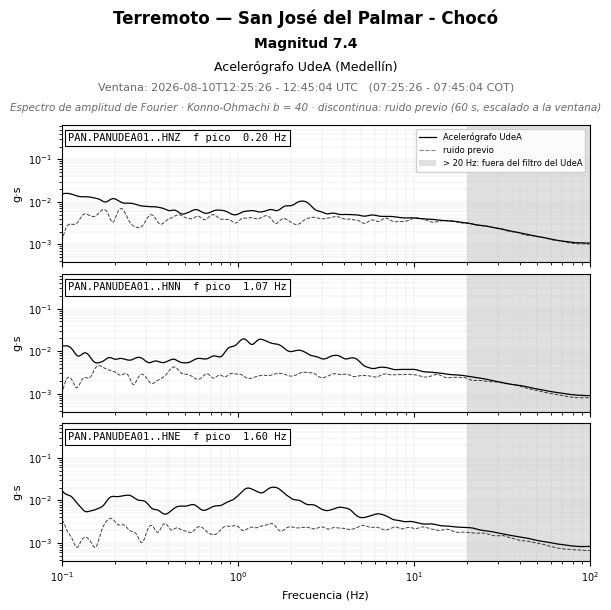

  guardado: output\terremoto_choco\espectros\registro_sgc\acelerografo\fourier_acelerografo_registro_sgc_g.png


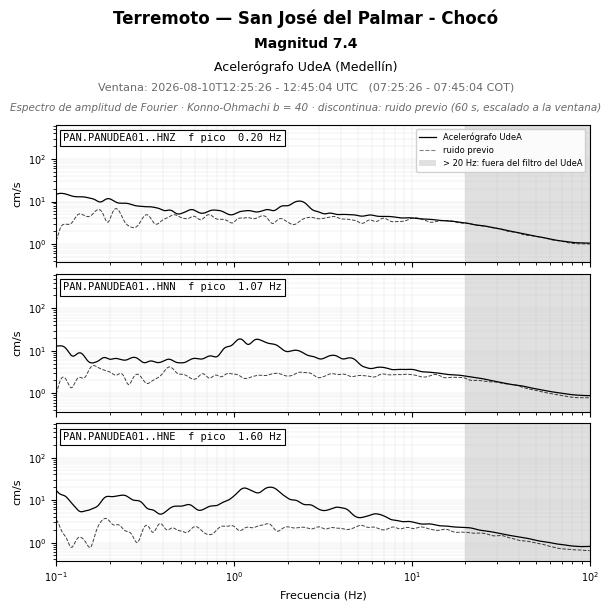

  guardado: output\terremoto_choco\espectros\registro_sgc\acelerografo\fourier_acelerografo_registro_sgc_cms2.png


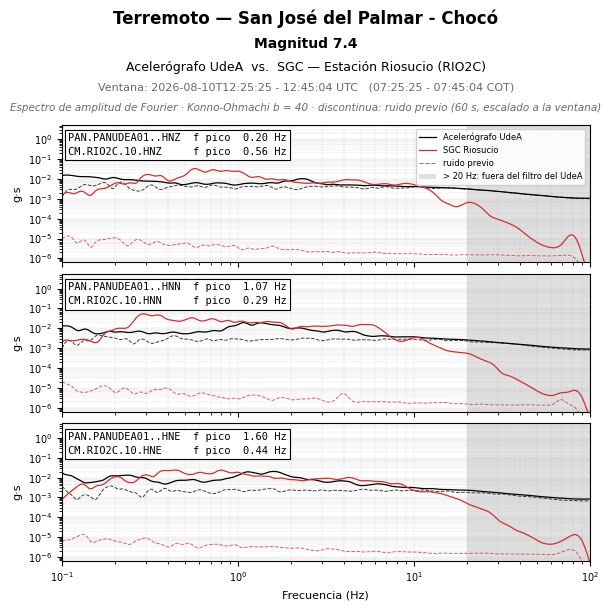

  guardado: output\terremoto_choco\espectros\registro_sgc\Riosucio\riosucio_RIO2C_10_fourier_junta_g.png


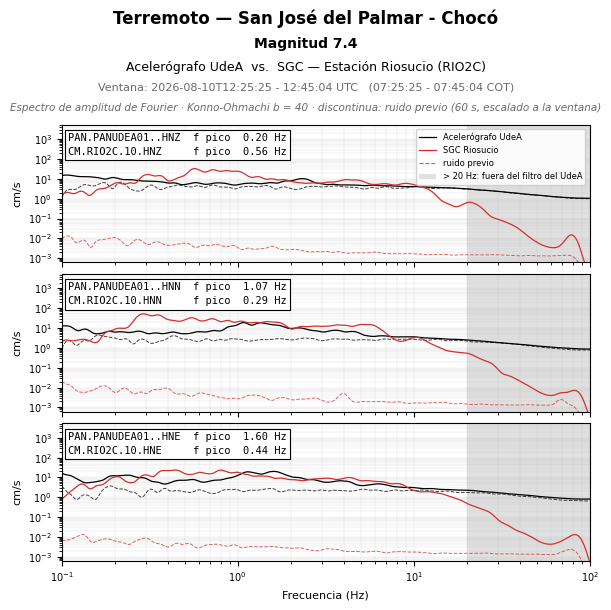

  guardado: output\terremoto_choco\espectros\registro_sgc\Riosucio\riosucio_RIO2C_10_fourier_junta_cms2.png


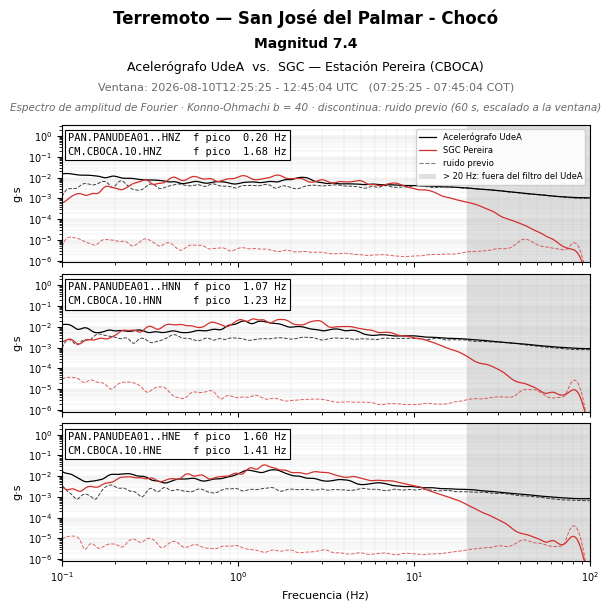

  guardado: output\terremoto_choco\espectros\registro_sgc\Pereira\pereira_CBOCA_10_fourier_junta_g.png


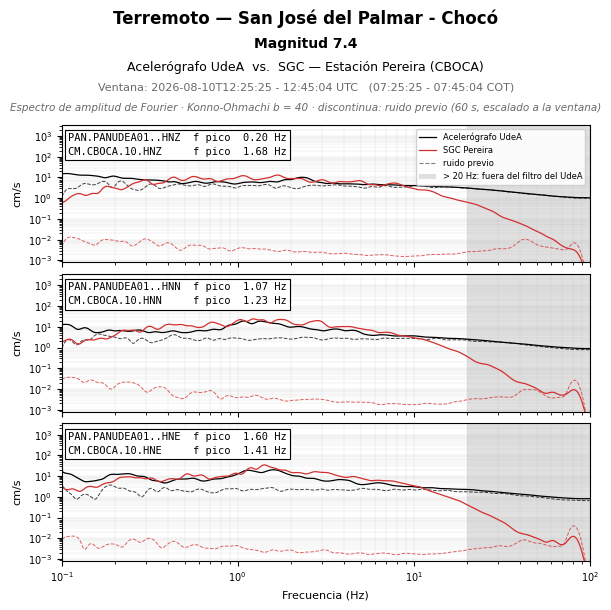

  guardado: output\terremoto_choco\espectros\registro_sgc\Pereira\pereira_CBOCA_10_fourier_junta_cms2.png


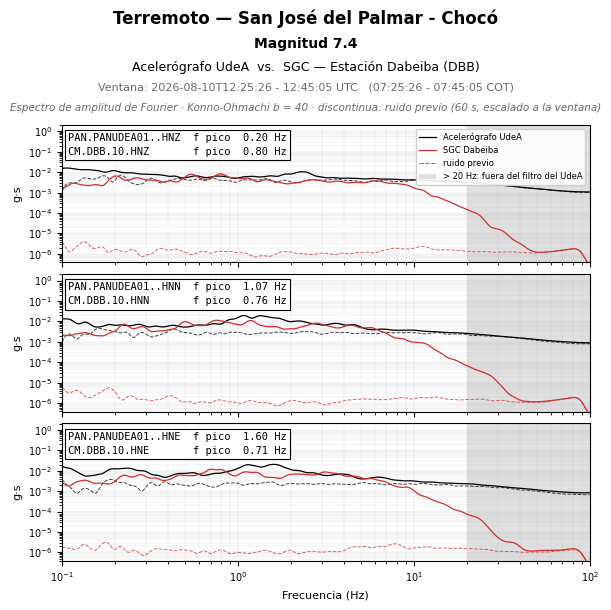

  guardado: output\terremoto_choco\espectros\registro_sgc\Dabeiba\dabeiba_DBB_10_fourier_junta_g.png


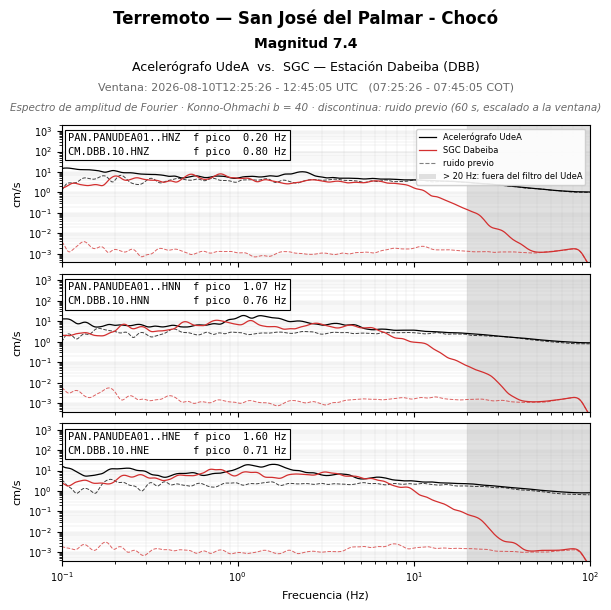

  guardado: output\terremoto_choco\espectros\registro_sgc\Dabeiba\dabeiba_DBB_10_fourier_junta_cms2.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


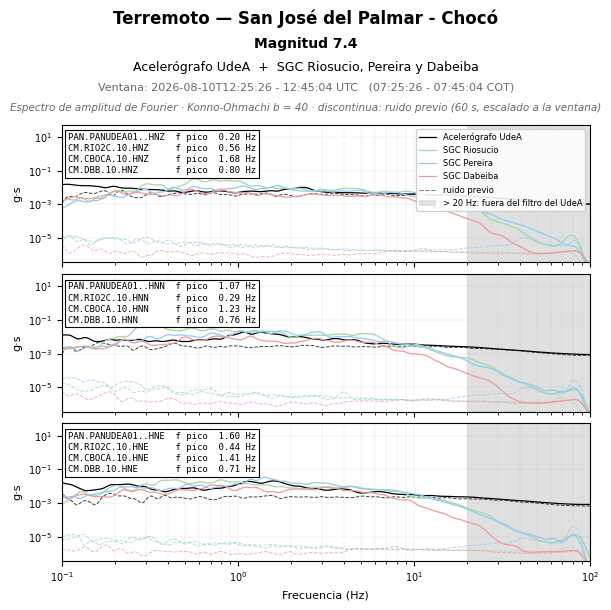

  guardado: output\terremoto_choco\espectros\registro_sgc\juntas_todas\juntas_todas_fourier_g.png


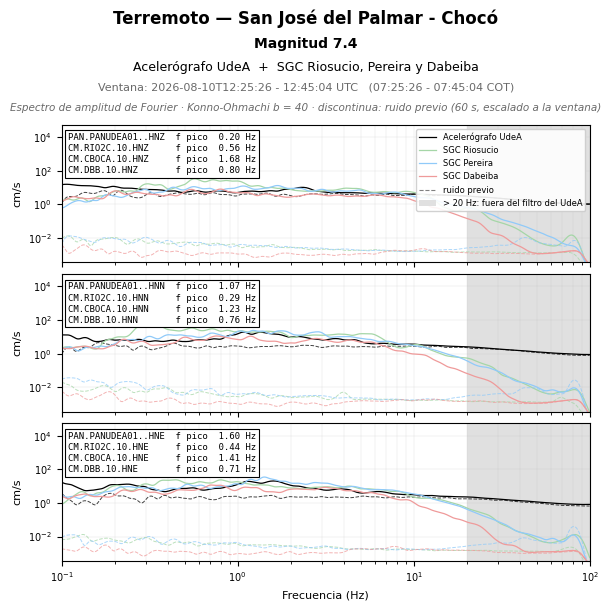

  guardado: output\terremoto_choco\espectros\registro_sgc\juntas_todas\juntas_todas_fourier_cms2.png
=== Ventana: desde_primera_alerta ===


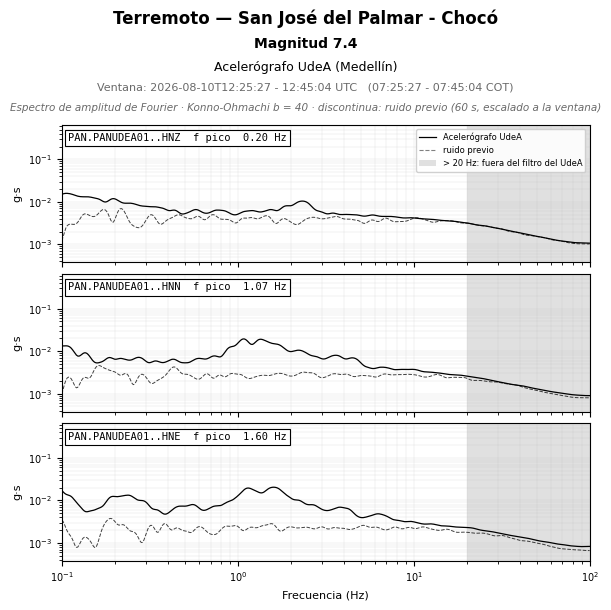

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\acelerografo\fourier_acelerografo_desde_primera_alerta_g.png


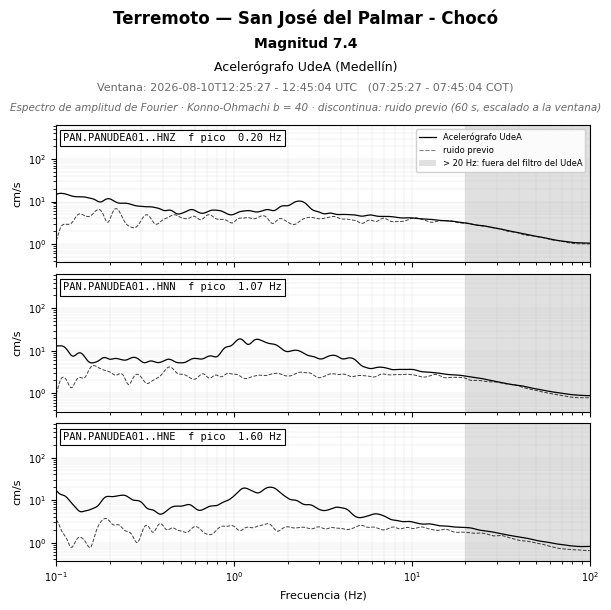

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\acelerografo\fourier_acelerografo_desde_primera_alerta_cms2.png


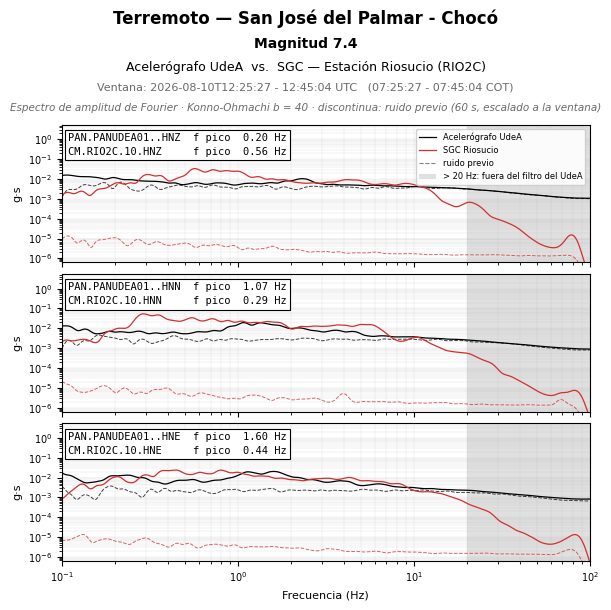

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_fourier_junta_g.png


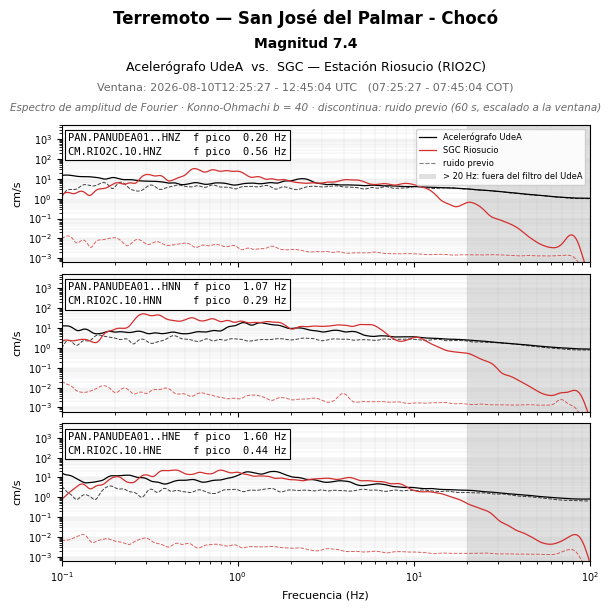

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_fourier_junta_cms2.png


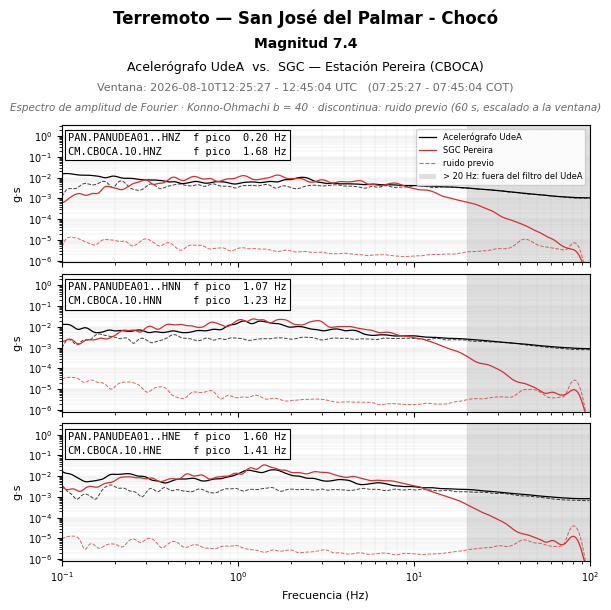

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Pereira\pereira_CBOCA_10_fourier_junta_g.png


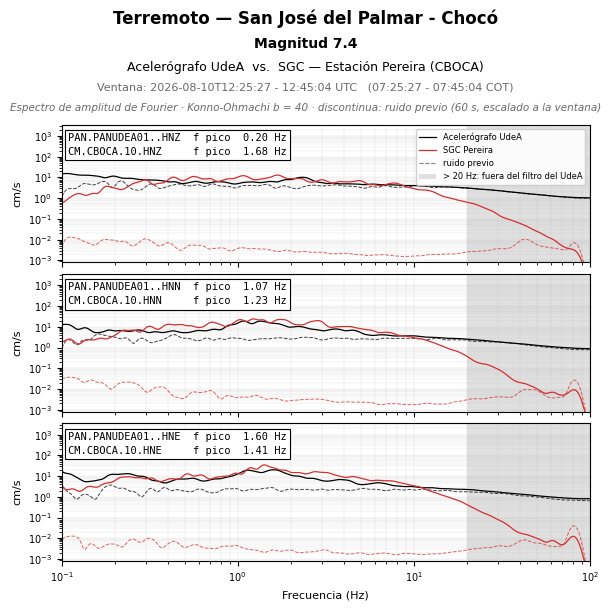

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Pereira\pereira_CBOCA_10_fourier_junta_cms2.png


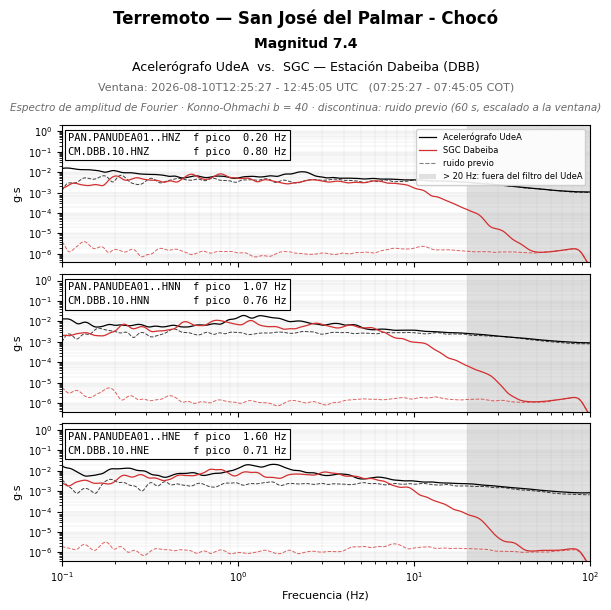

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_fourier_junta_g.png


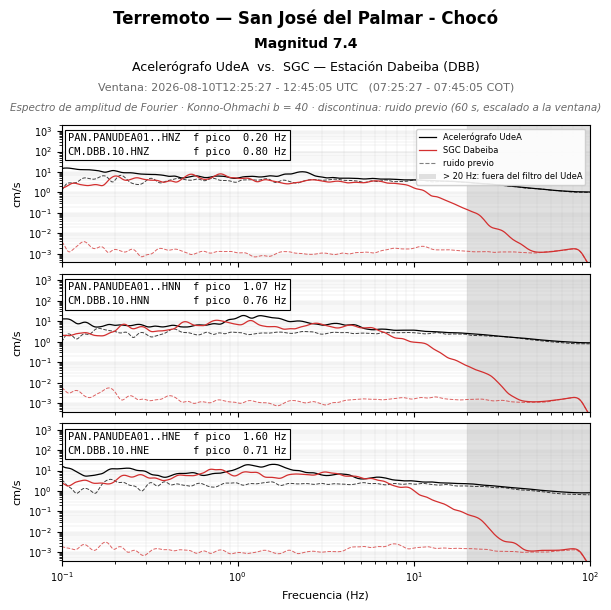

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_fourier_junta_cms2.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


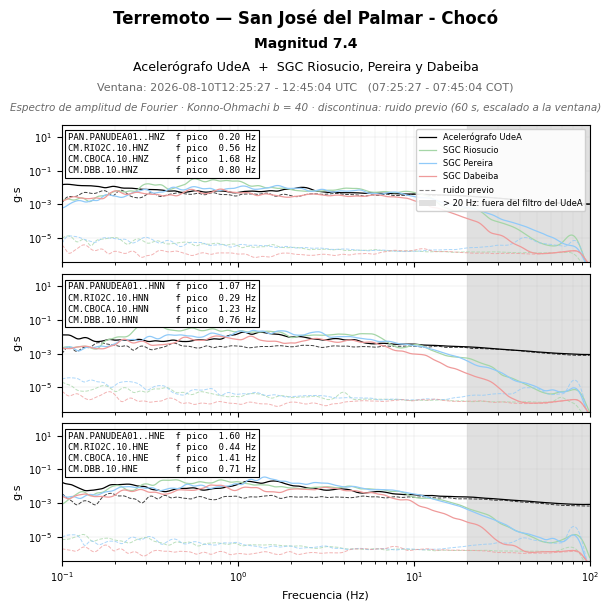

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\juntas_todas\juntas_todas_fourier_g.png


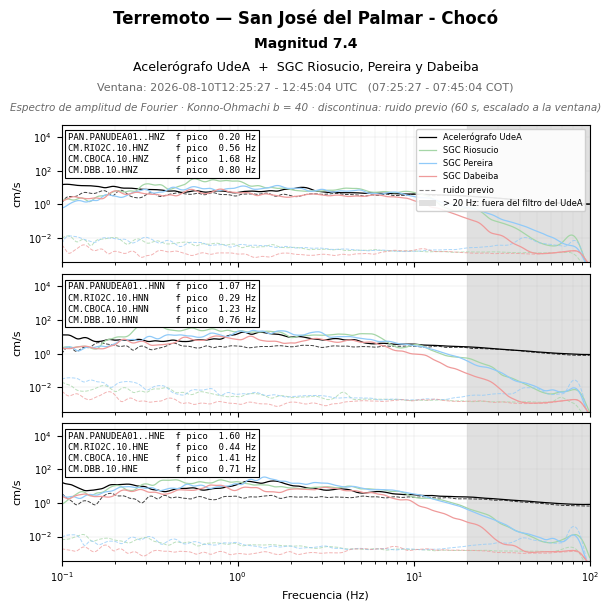

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\juntas_todas\juntas_todas_fourier_cms2.png
=== Ventana: sismo ===


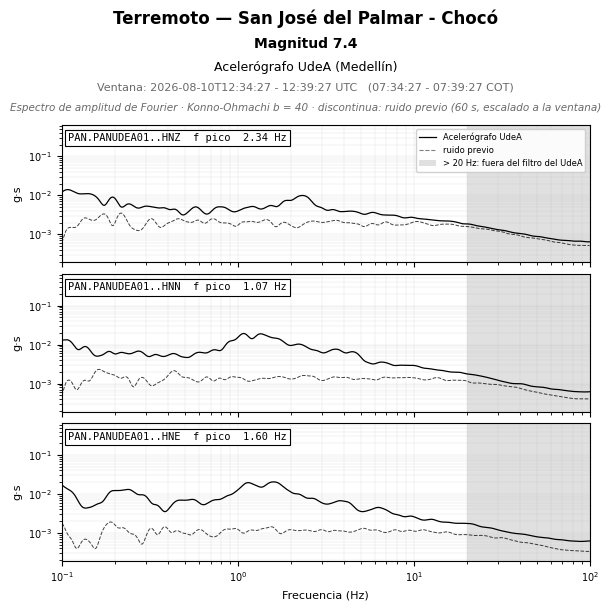

  guardado: output\terremoto_choco\espectros\sismo\acelerografo\fourier_acelerografo_sismo_g.png


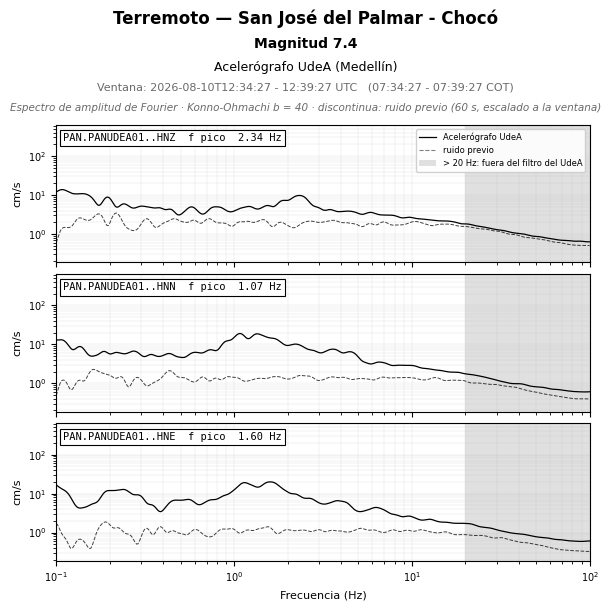

  guardado: output\terremoto_choco\espectros\sismo\acelerografo\fourier_acelerografo_sismo_cms2.png


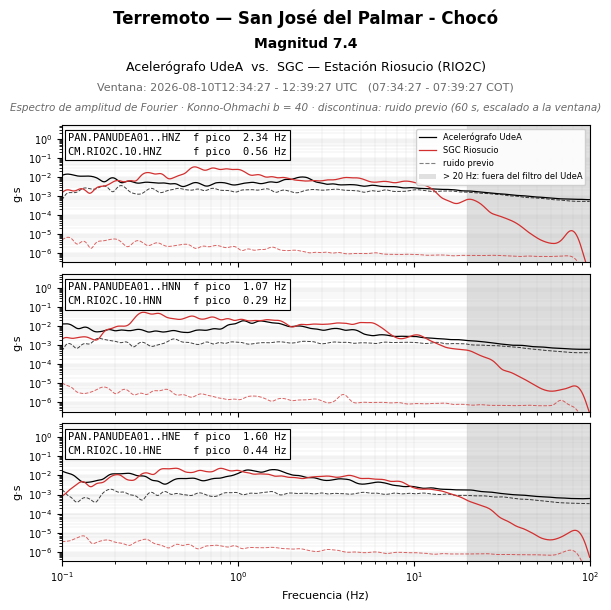

  guardado: output\terremoto_choco\espectros\sismo\Riosucio\riosucio_RIO2C_10_fourier_junta_g.png


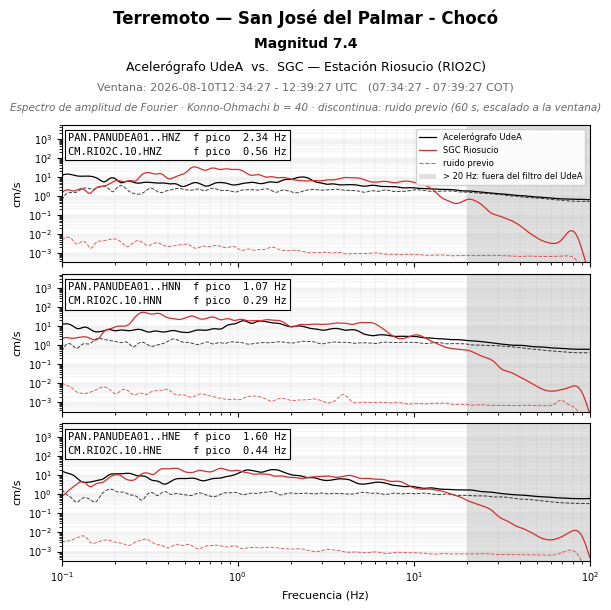

  guardado: output\terremoto_choco\espectros\sismo\Riosucio\riosucio_RIO2C_10_fourier_junta_cms2.png


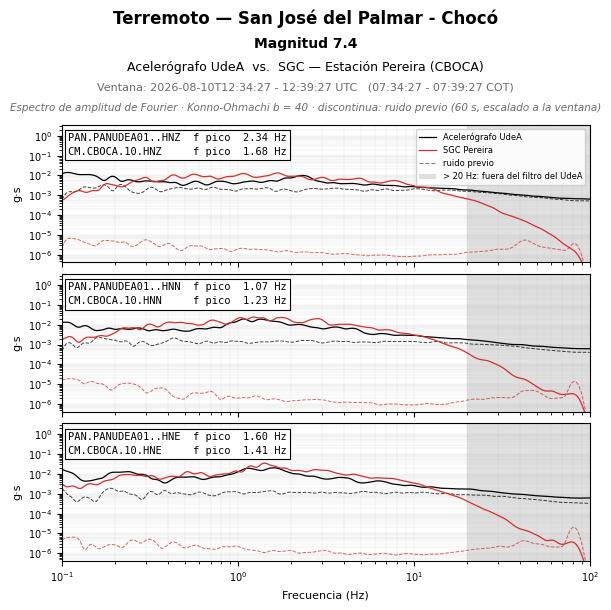

  guardado: output\terremoto_choco\espectros\sismo\Pereira\pereira_CBOCA_10_fourier_junta_g.png


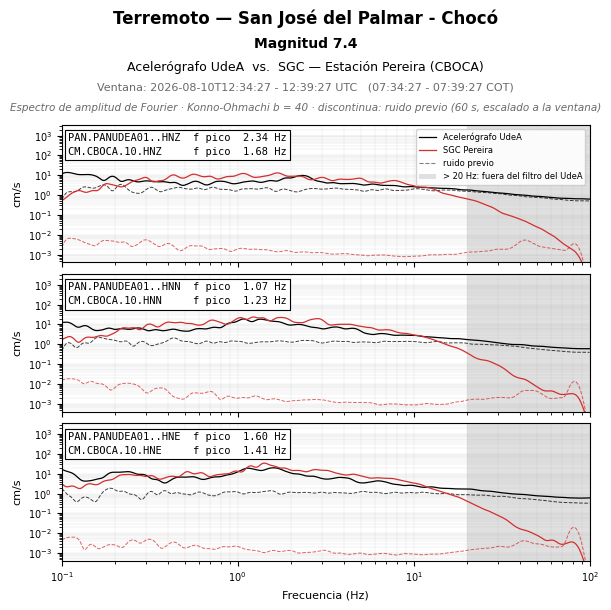

  guardado: output\terremoto_choco\espectros\sismo\Pereira\pereira_CBOCA_10_fourier_junta_cms2.png


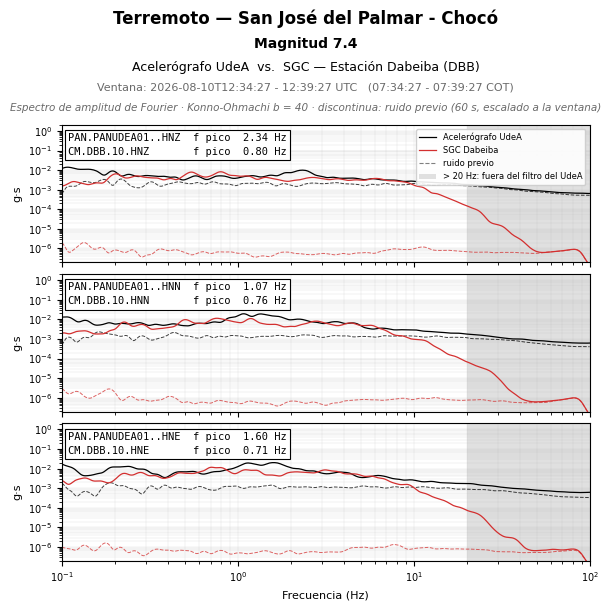

  guardado: output\terremoto_choco\espectros\sismo\Dabeiba\dabeiba_DBB_10_fourier_junta_g.png


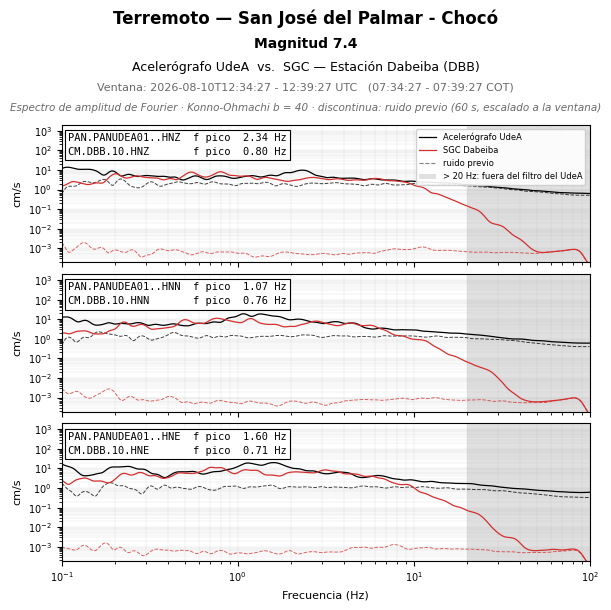

  guardado: output\terremoto_choco\espectros\sismo\Dabeiba\dabeiba_DBB_10_fourier_junta_cms2.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


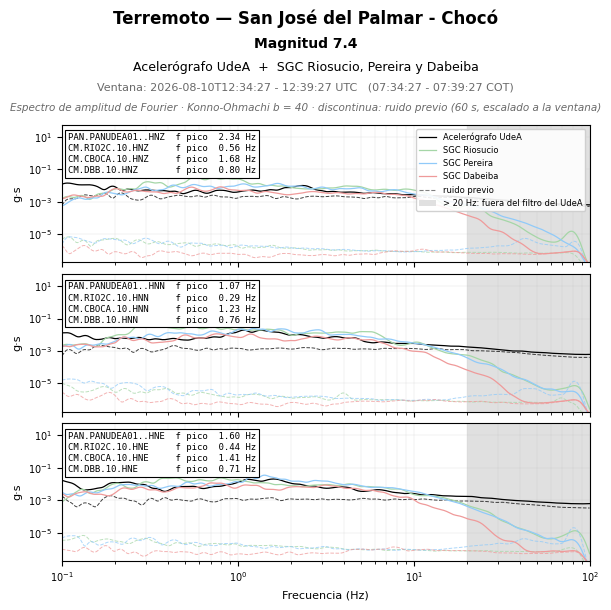

  guardado: output\terremoto_choco\espectros\sismo\juntas_todas\juntas_todas_fourier_g.png


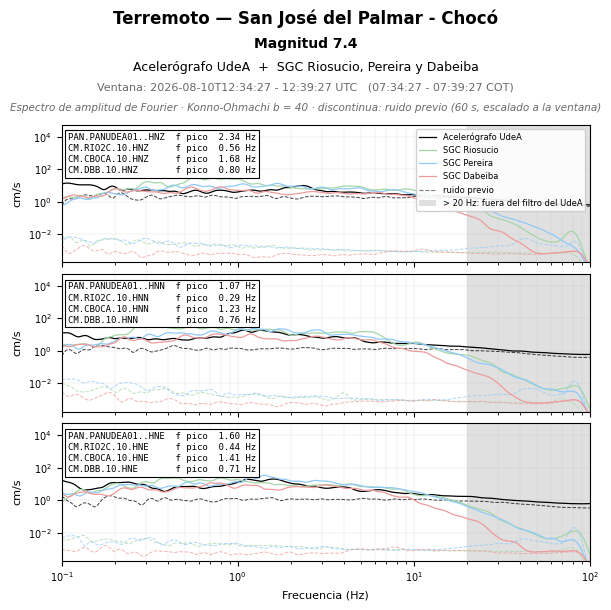

  guardado: output\terremoto_choco\espectros\sismo\juntas_todas\juntas_todas_fourier_cms2.png


In [11]:
if GENERAR_FOURIER:
    for v in VENTANAS:
        nombre_v = nombre_ventana(v)
        print(f"=== Ventana: {nombre_v} ===")
        try:
            t0, t1 = resolver_ventana(v, RECON, ESTACIONES, ORIGEN_EVENTO)
        except ValueError as e:
            PROBLEMAS.append(f"Acelerógrafo UdeA, ventana {nombre_v}: {e}")
            print(f"[AVISO] {e}")
        else:
            for u in UNIDADES:
                plot_fourier([item_acelerografo(u, t0, t1)], u,
                             DIR_SALIDA / nombre_v / "acelerografo" / f"fourier_acelerografo_{nombre_v}_{_SUFIJO_UNIDAD[u]}.png",
                             ACELEROGRAFO["nombre"], t0, t1)

        for est in ESTACIONES:
            try:
                t0, t1 = resolver_ventana(v, RECON, [est], ORIGEN_EVENTO)
            except ValueError as e:
                PROBLEMAS.append(f"{est['nombre']}, ventana {nombre_v}: {e}")
                print(f"[AVISO] {est['nombre']}: {e}")
                continue
            texto = f"{ACELEROGRAFO['leyenda']}  vs.  SGC — Estación {est['nombre']} ({est['codigo']})"
            for u in (UNIDADES if est["calibrada"] else UNIDADES[:1]):
                suf = _SUFIJO_UNIDAD[u] if est["calibrada"] else "norm"
                plot_fourier([item_acelerografo(u, t0, t1), item_estacion(est, u, t0, t1)], u,
                             DIR_SALIDA / nombre_v / est["nombre"] / f"{est['slug']}_fourier_junta_{suf}.png",
                             texto, t0, t1)

        correr_grupos(v, espectrograma=False)
else:
    print("GENERAR_FOURIER = False: se omiten los espectros de Fourier.")

## §13 — Espectrogramas comparativos

La hora completa reconstruida del Acelerógrafo UdeA y, por cada ventana: el UdeA solo, el UdeA junto a cada
estación y cada grupo de estaciones. Los instrumentos en la misma unidad comparten la escala de color, así que
los colores se pueden comparar directamente entre columnas.

=== Hora completa ===


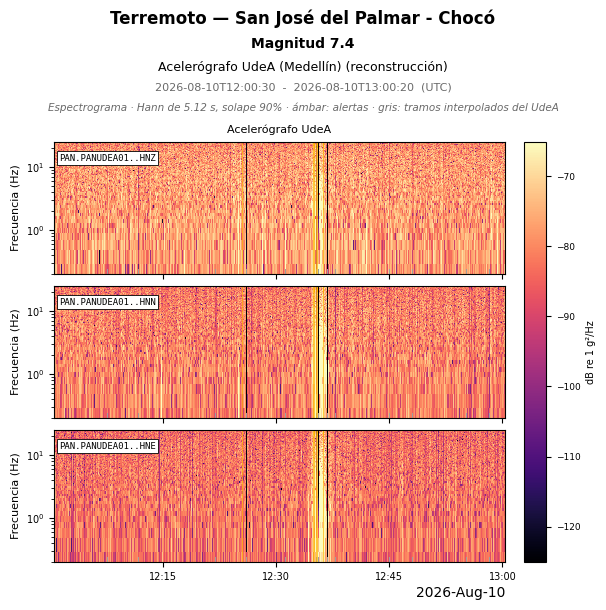

  guardado: output\terremoto_choco\espectros\acelerografo\espectrograma_hora_completa_{UTC,LOCAL}.png
=== Ventana: registro_sgc ===


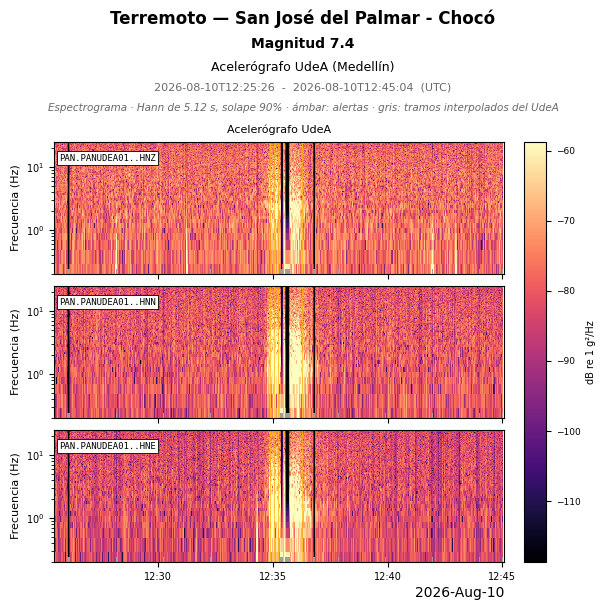

  guardado: output\terremoto_choco\espectros\registro_sgc\acelerografo\espectrograma_acelerografo_registro_sgc_{UTC,LOCAL}.png


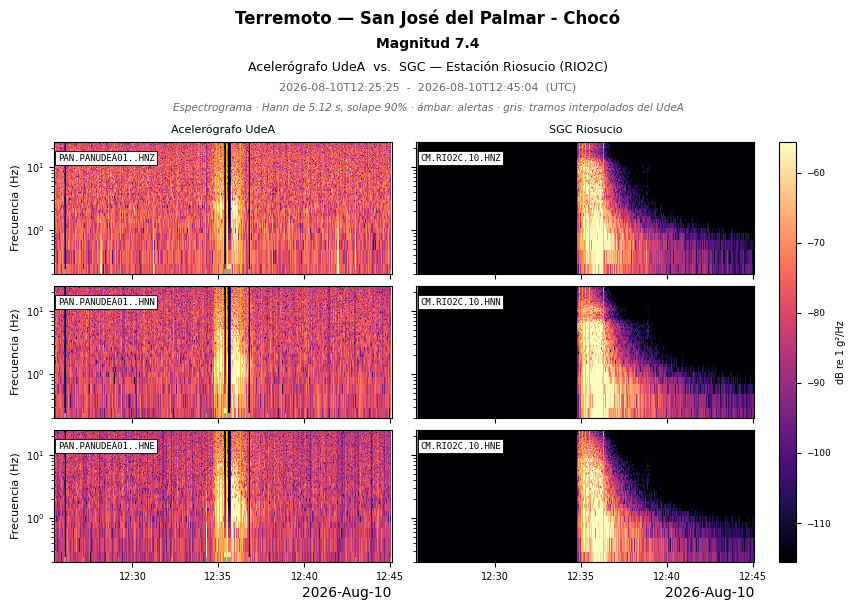

  guardado: output\terremoto_choco\espectros\registro_sgc\Riosucio\riosucio_RIO2C_10_espectrograma_junta_{UTC,LOCAL}.png


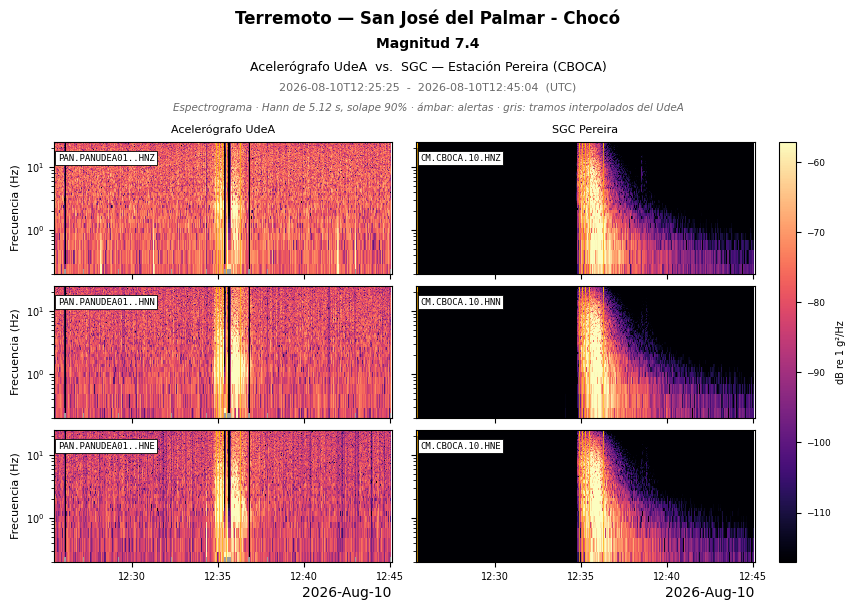

  guardado: output\terremoto_choco\espectros\registro_sgc\Pereira\pereira_CBOCA_10_espectrograma_junta_{UTC,LOCAL}.png


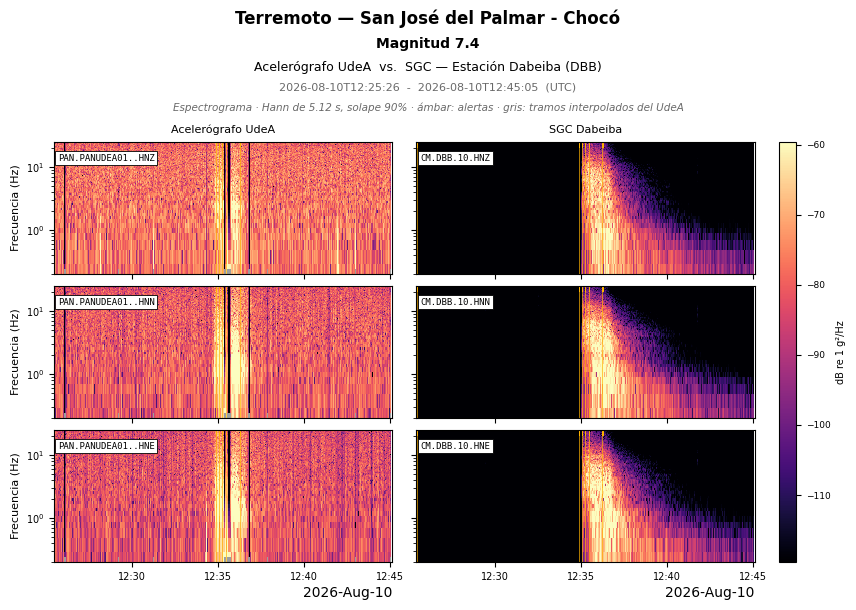

  guardado: output\terremoto_choco\espectros\registro_sgc\Dabeiba\dabeiba_DBB_10_espectrograma_junta_{UTC,LOCAL}.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


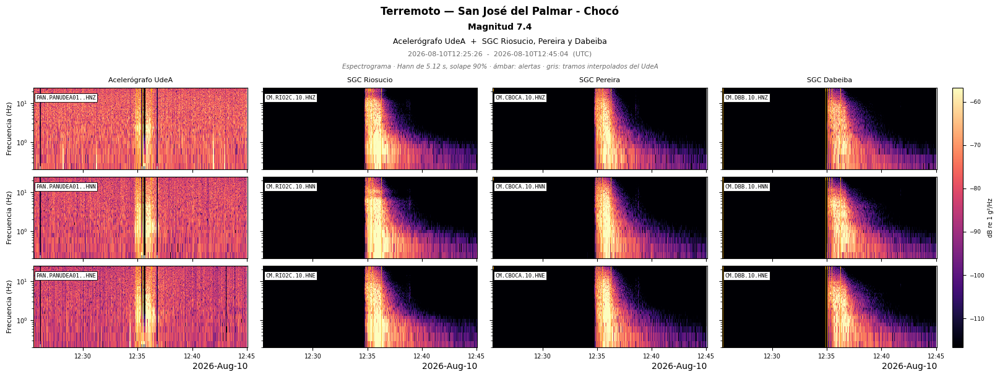

  guardado: output\terremoto_choco\espectros\registro_sgc\juntas_todas\juntas_todas_espectrograma_{UTC,LOCAL}.png
=== Ventana: desde_primera_alerta ===


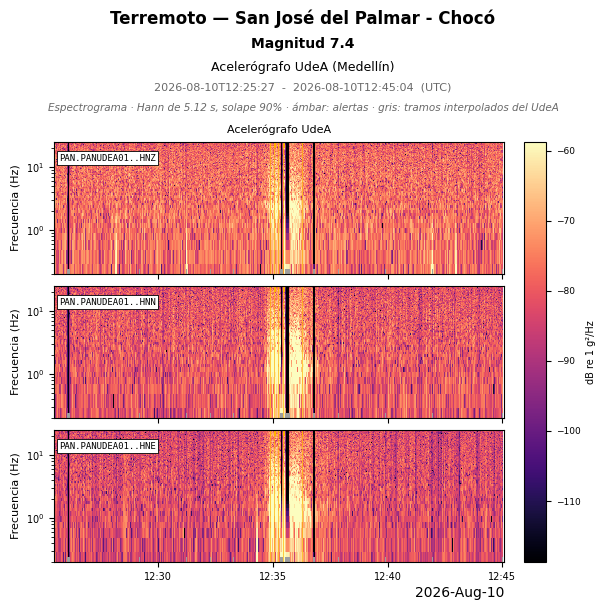

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\acelerografo\espectrograma_acelerografo_desde_primera_alerta_{UTC,LOCAL}.png


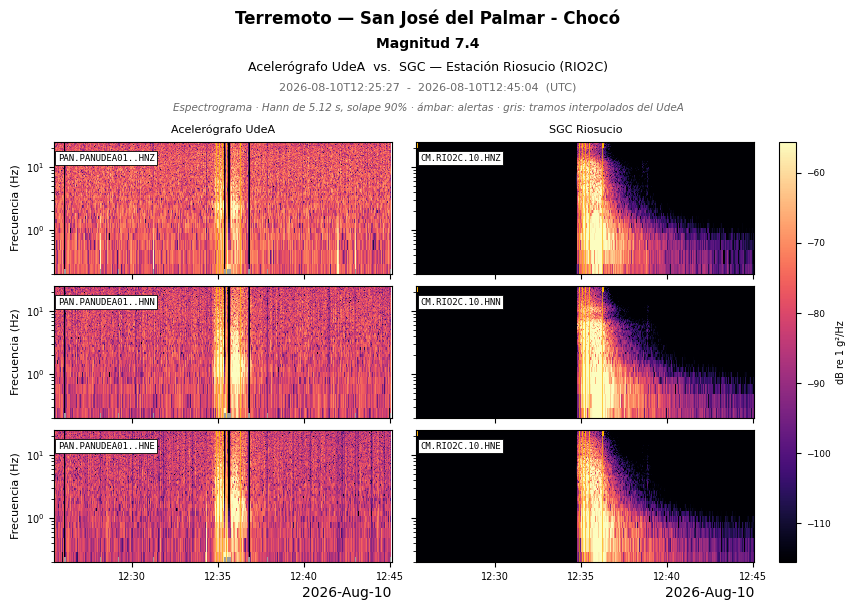

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Riosucio\riosucio_RIO2C_10_espectrograma_junta_{UTC,LOCAL}.png


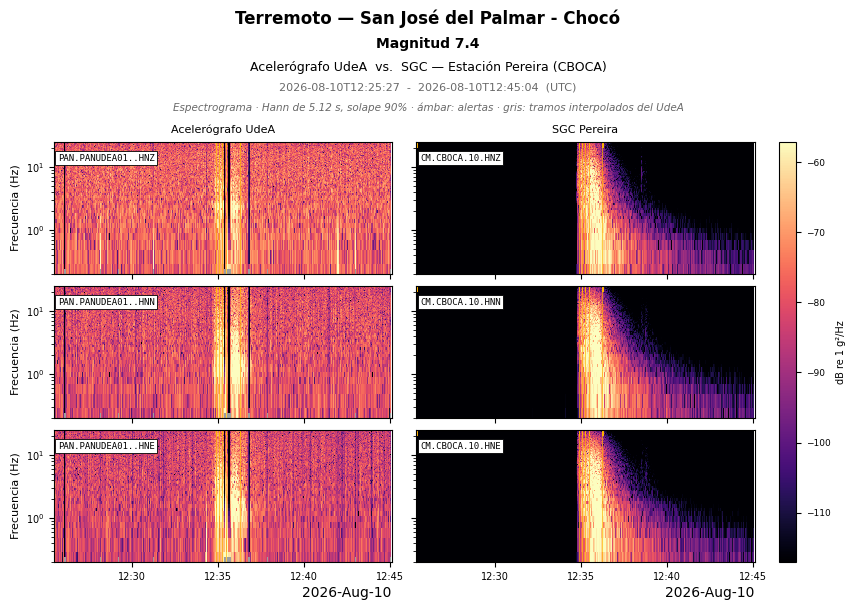

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Pereira\pereira_CBOCA_10_espectrograma_junta_{UTC,LOCAL}.png


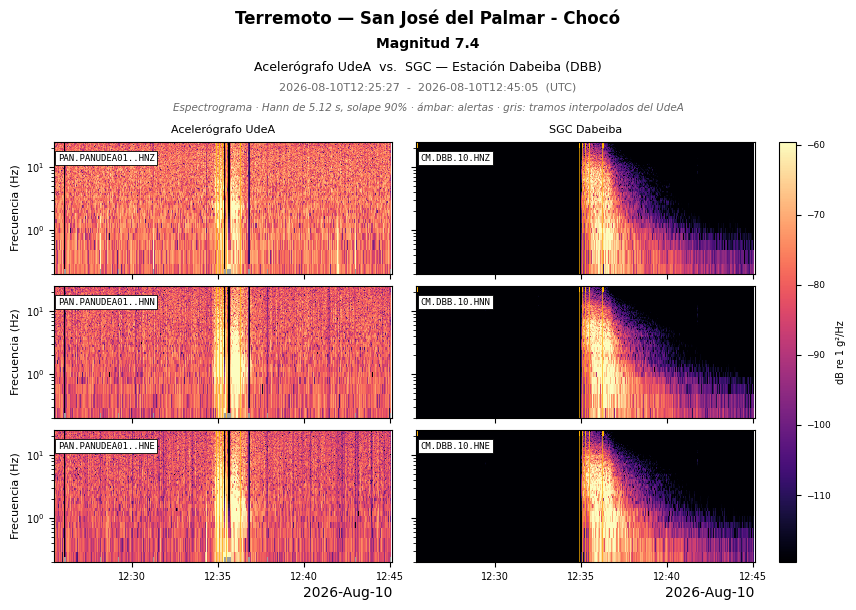

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\Dabeiba\dabeiba_DBB_10_espectrograma_junta_{UTC,LOCAL}.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


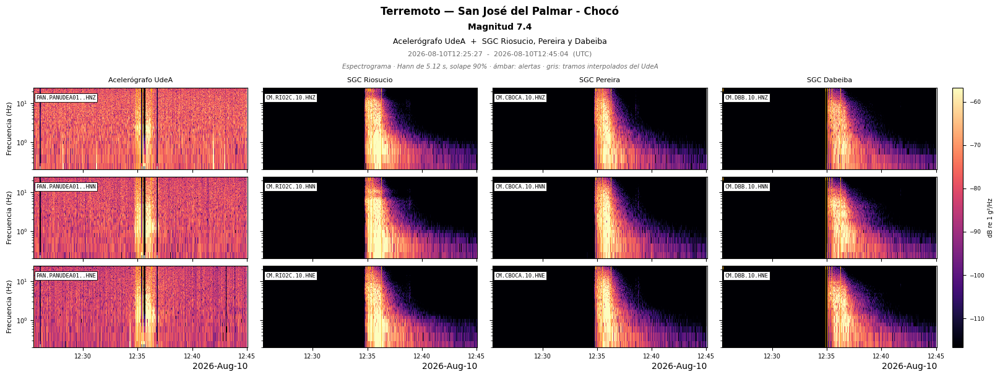

  guardado: output\terremoto_choco\espectros\desde_primera_alerta\juntas_todas\juntas_todas_espectrograma_{UTC,LOCAL}.png
=== Ventana: sismo ===


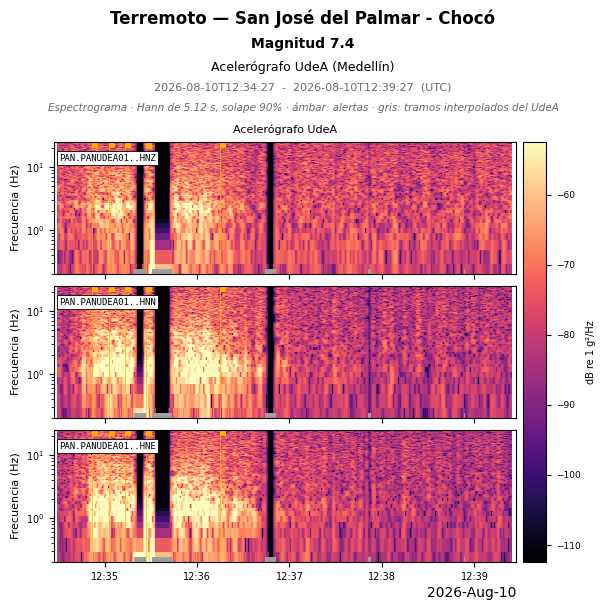

  guardado: output\terremoto_choco\espectros\sismo\acelerografo\espectrograma_acelerografo_sismo_{UTC,LOCAL}.png


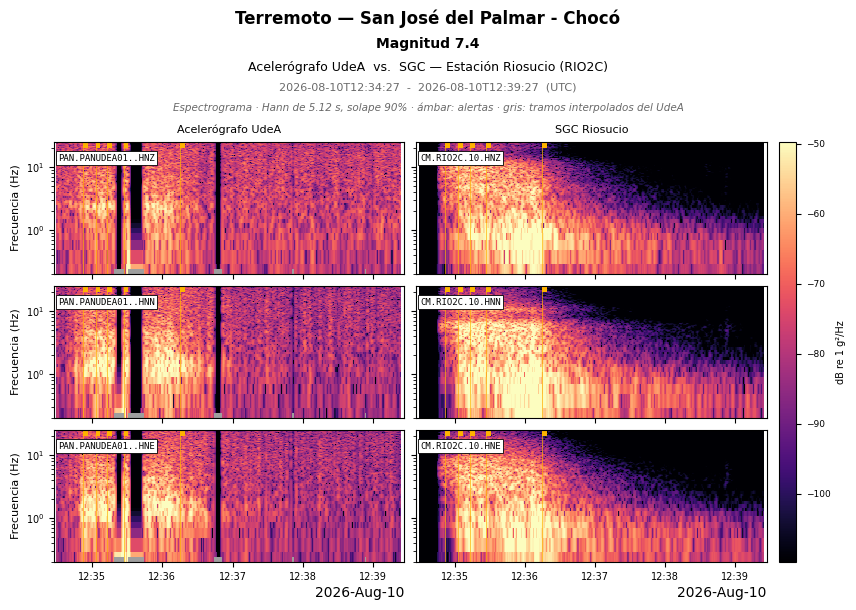

  guardado: output\terremoto_choco\espectros\sismo\Riosucio\riosucio_RIO2C_10_espectrograma_junta_{UTC,LOCAL}.png


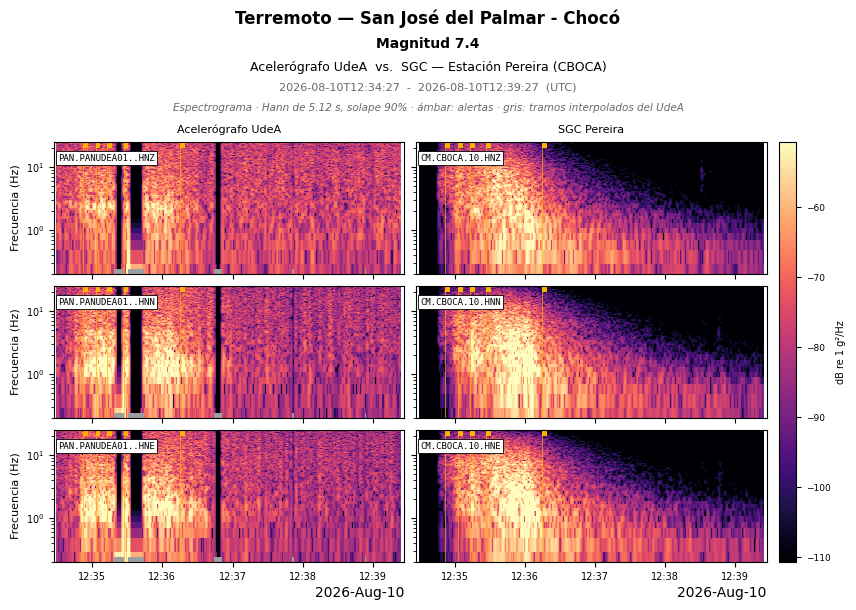

  guardado: output\terremoto_choco\espectros\sismo\Pereira\pereira_CBOCA_10_espectrograma_junta_{UTC,LOCAL}.png


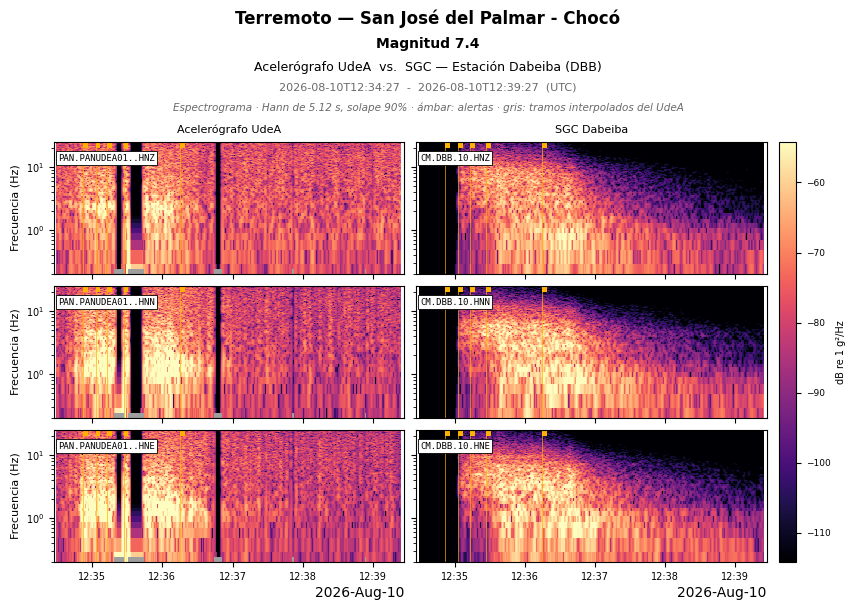

  guardado: output\terremoto_choco\espectros\sismo\Dabeiba\dabeiba_DBB_10_espectrograma_junta_{UTC,LOCAL}.png
--- grupo todas (Riosucio, Pereira y Dabeiba)


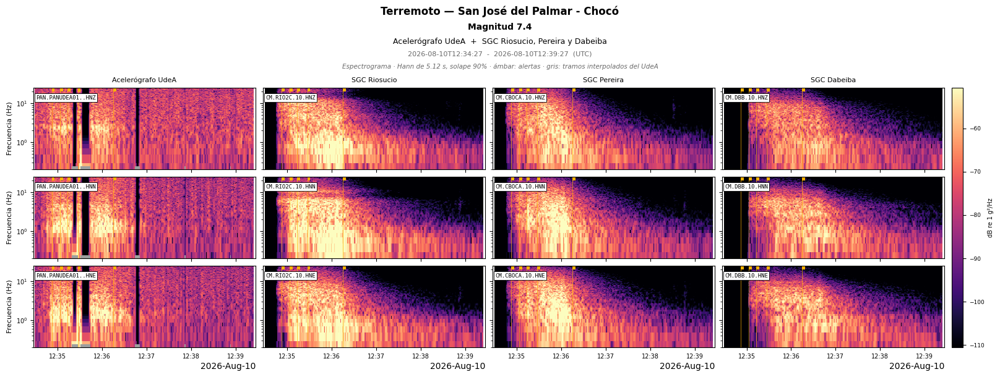

  guardado: output\terremoto_choco\espectros\sismo\juntas_todas\juntas_todas_espectrograma_{UTC,LOCAL}.png


In [12]:
if GENERAR_ESPECTROGRAMAS:
    _u_esp = ESPECTROGRAMA["unidad"]
    print("=== Hora completa ===")
    plot_espectrograma([registro_acelerografo(_u_esp)], DIR_SALIDA / "acelerografo" / "espectrograma_hora_completa.png",
                       f"{ACELEROGRAFO['nombre']} (reconstrucción)", RECON["alert_windows"])

    for v in VENTANAS:
        nombre_v = nombre_ventana(v)
        print(f"=== Ventana: {nombre_v} ===")
        try:
            t0, t1 = resolver_ventana(v, RECON, ESTACIONES, ORIGEN_EVENTO)
        except ValueError as e:
            PROBLEMAS.append(f"Acelerógrafo UdeA, ventana {nombre_v}: {e}")
            print(f"[AVISO] {e}")
        else:
            plot_espectrograma([registro_acelerografo(_u_esp, t0, t1)],
                               DIR_SALIDA / nombre_v / "acelerografo" / f"espectrograma_acelerografo_{nombre_v}.png",
                               ACELEROGRAFO["nombre"], RECON["alert_windows"], t0, t1)

        for est in ESTACIONES:
            try:
                t0, t1 = resolver_ventana(v, RECON, [est], ORIGEN_EVENTO)
            except ValueError as e:
                print(f"[AVISO] {est['nombre']}: {e}")
                continue
            texto = f"{ACELEROGRAFO['leyenda']}  vs.  SGC — Estación {est['nombre']} ({est['codigo']})"
            plot_espectrograma([registro_acelerografo(_u_esp, t0, t1), registro_estacion(est, _u_esp, t0=t0, t1=t1)],
                               DIR_SALIDA / nombre_v / est["nombre"] / f"{est['slug']}_espectrograma_junta.png",
                               texto, RECON["alert_windows"], t0, t1)

        correr_grupos(v, fourier=False)
else:
    print("GENERAR_ESPECTROGRAMAS = False: se omiten los espectrogramas.")

**Ejemplo para armar un grupo a mano** (descomentar y ejecutar): cualquier combinación de estaciones, en el orden
que se quiera y en cualquier ventana. Genera el espectro de Fourier y el espectrograma.

In [13]:
# juntar_espectros(["Pereira", "Dabeiba"],
#                  {"nombre": "sismo", "modo": "relativa_origen", "antes_s": 0, "despues_s": 240},
#                  nombre_grupo="pereira_dabeiba")

## §14 — Espectrogramas de las alertas (vista CNN)

Cada `.bin` de `eventos/` es la ventana de 4 s (800 muestras) que analizó la CNN del nodo cuando disparó una
alerta. Aquí se le calcula el mismo espectrograma que recibe el modelo, **65 frecuencias × 11 ventanas × 3
ejes**, con `log10(PSD + 1e-12)` en g²/Hz. En el nombre del archivo, `sNN` es el puntaje de la CNN × 100.

La tabla da también el PGA de cada eje (la otra entrada del modelo) y la media del log-PSD. Si esa media es menor
que `CNN_MIN_LOG_PSD = -11`, el nodo ni siquiera evalúa la CNN: la señal es solo ruido de cuantización.

Archivo                            Hora local Puntaje  PGA EW / NS / VER (g)    media log10 PSD  Forma
evento_20260810_072527_s94.bin     07:25:27      0.94  0.0117 / 0.0156 / 0.0117     -7.50 (evalúa)  (65, 11, 3)
evento_20260810_073452_s97.bin     07:34:52      0.97  0.0117 / 0.0156 / 0.0078     -7.48 (evalúa)  (65, 11, 3)
evento_20260810_073503_s99.bin     07:35:03      0.99  0.0117 / 0.0156 / 0.0156     -7.33 (evalúa)  (65, 11, 3)
evento_20260810_073513_s99.bin     07:35:13      0.99  0.0156 / 0.0117 / 0.0156     -7.33 (evalúa)  (65, 11, 3)
evento_20260810_073527_s99.bin     07:35:27      0.99  0.0195 / 0.0195 / 0.0156     -7.24 (evalúa)  (65, 11, 3)
evento_20260810_073615_s99.bin     07:36:15      0.99  0.0195 / 0.0273 / 0.0156     -7.17 (evalúa)  (65, 11, 3)


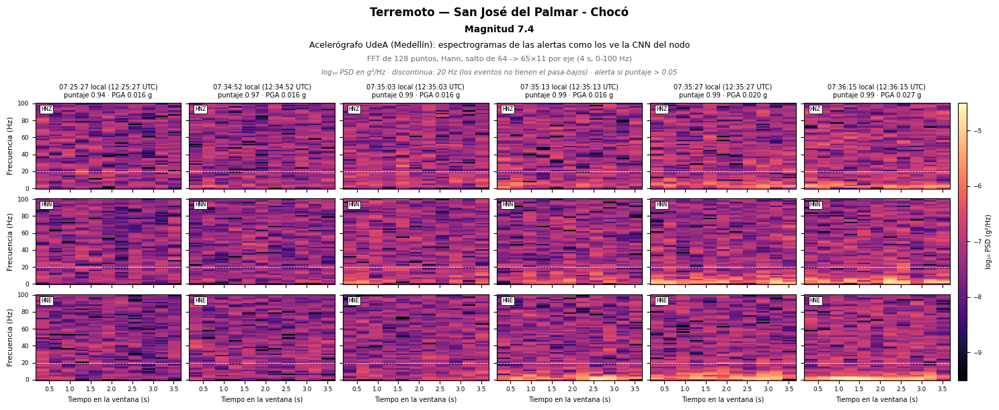

  guardado: output\terremoto_choco\espectros\alertas_cnn\alertas_cnn_1.png


In [14]:
ALERTAS_CNN = []
if GENERAR_CNN:
    ALERTAS_CNN = cargar_alertas_cnn(evento_files)
    if not ALERTAS_CNN:
        print("No hay archivos de eventos: no hay alertas que mostrar.")
    else:
        print(f"{'Archivo':<34} {'Hora local':<10} {'Puntaje':>7}  {'PGA EW / NS / VER (g)':<24} {'media log10 PSD':>15}  Forma")
        for a in ALERTAS_CNN:
            pga = " / ".join(f"{p:.4f}" for p in a["pga_g"])
            estado = "evalúa" if a["media_log_psd"] >= CNN_MIN_LOG_PSD else "bajo el umbral"
            print(f"{a['archivo']:<34} {a['hora_local']:%H:%M:%S}   {a['puntaje']:>7.2f}  {pga:<24} "
                  f"{a['media_log_psd']:>9.2f} ({estado})  {a['spec'].shape}")
            if a["spec"].shape != (CNN_NPERSEG // 2 + 1, 11, 3):
                PROBLEMAS.append(f"{a['archivo']}: {a['n']} muestras, el espectrograma CNN no es de 65x11x3")
        por_figura = CNN["alertas_por_figura"]
        for k in range(0, len(ALERTAS_CNN), por_figura):
            plot_alertas_cnn(ALERTAS_CNN[k:k + por_figura], DIR_SALIDA / "alertas_cnn" / f"alertas_cnn_{k // por_figura + 1}.png")
else:
    print("GENERAR_CNN = False: se omite la vista CNN.")

## §15 — Resumen

Por cada ventana, la frecuencia pico y la banda útil (SNR ≥ `snr_min`) de cada componente (Z, N, E) de cada
instrumento, y el porcentaje de muestras interpoladas del Acelerógrafo UdeA. Después vienen el resumen de las
alertas CNN, los avisos acumulados y los archivos generados.

In [15]:
_orden = [LABELS.index(c) for c in ORDEN_FILAS]
_canales = "/".join(CANAL_POR_COMP[c] for c in ORDEN_FILAS)
_u_res = UNIDADES[0]


def _txt_banda(b):
    return "   —   " if np.isnan(b[0]) else f"{b[0]:.2g}-{b[1]:.2g}"


def _fila_resumen(nombre, it, nota):
    if it is None:
        return
    picos = " / ".join(f"{it['f_pico'][i]:.2f}" for i in _orden)
    bandas = " / ".join(_txt_banda(it["banda"][i]) for i in _orden)
    print(f"  {nombre:<20} {picos:<20} {bandas:<34} {nota}")


for v in VENTANAS:
    nombre_v = nombre_ventana(v)
    print(f"\nVentana {nombre_v} -- componentes {_canales}")
    print(f"  {'Instrumento':<20} {'f pico (Hz)':<20} {'banda útil SNR>=' + str(FOURIER['snr_min']) + ' (Hz)':<34} Nota")
    try:
        t0, t1 = resolver_ventana(v, RECON, ESTACIONES, ORIGEN_EVENTO)
        m = (RECON["t_utc"] >= t0) & (RECON["t_utc"] <= t1)
        interp = 100 * np.mean(RECON["status"][m] == 3) if m.any() else np.nan
        _fila_resumen(ACELEROGRAFO["leyenda"], item_acelerografo(_u_res, t0, t1), f"{interp:.1f} % interpolado")
    except ValueError:
        pass
    for est in ESTACIONES:
        try:
            t0, t1 = resolver_ventana(v, RECON, [est], ORIGEN_EVENTO)
        except ValueError:
            continue
        _fila_resumen(f"SGC {est['nombre']}", item_estacion(est, _u_res, t0, t1), est["fuente"])

if ALERTAS_CNN:
    n_eval = sum(a["media_log_psd"] >= CNN_MIN_LOG_PSD for a in ALERTAS_CNN)
    print(f"\nAlertas CNN: {len(ALERTAS_CNN)} (puntaje {min(a['puntaje'] for a in ALERTAS_CNN):.2f}-"
          f"{max(a['puntaje'] for a in ALERTAS_CNN):.2f}); {n_eval} con media de log10 PSD >= {CNN_MIN_LOG_PSD:g}")

print("\nAvisos:" if PROBLEMAS else "\nSin avisos.")
for p in dict.fromkeys(PROBLEMAS):
    print(f"  - {p}")

print(f"\nArchivos generados en {DIR_SALIDA}:")
_total_png = 0
for carpeta in sorted({p.parent for p in DIR_SALIDA.rglob("*.png")}):
    n_png = len(list(carpeta.glob("*.png")))
    _total_png += n_png
    print(f"  {str(carpeta.relative_to(DIR_SALIDA)):<45} {n_png:3d} PNG")
print(f"  {'TOTAL':<45} {_total_png:3d} PNG")


Ventana registro_sgc -- componentes Z/N/E
  Instrumento          f pico (Hz)          banda útil SNR>=3 (Hz)             Nota
  Acelerógrafo UdeA    0.20 / 1.07 / 1.60      —    / 0.83-2.4 / 0.66-2.9      4.8 % interpolado
  SGC Riosucio         0.56 / 0.29 / 0.44   0.1-56 / 0.1-59 / 0.1-1e+02        .mseed calibrado con .anc
  SGC Pereira          1.68 / 1.23 / 1.41   0.1-58 / 0.1-39 / 0.1-39           .mseed calibrado con .anc
  SGC Dabeiba          0.80 / 0.76 / 0.71   0.1-39 / 0.1-33 / 0.1-33           .mseed calibrado con .anc

Ventana desde_primera_alerta -- componentes Z/N/E
  Instrumento          f pico (Hz)          banda útil SNR>=3 (Hz)             Nota
  Acelerógrafo UdeA    0.20 / 1.07 / 1.60      —    / 0.83-2.4 / 0.66-2.9      4.8 % interpolado
  SGC Riosucio         0.56 / 0.29 / 0.44   0.1-56 / 0.1-59 / 0.1-1e+02        .mseed calibrado con .anc
  SGC Pereira          1.68 / 1.23 / 1.41   0.1-58 / 0.1-39 / 0.1-39           .mseed calibrado con .anc
  SGC Dabeiba      